# Contexto, Objetivo e Hipóteses do Projeto

# Carregamento de Dados e Entendimento Inicial dos Dados

In [1]:
# ============================================================
# 1. Padrão e Visualização
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
# Para visualização do SHAP no notebook
import shap 

# ============================================================
# 2. Estatística e Matemática
# ============================================================
from scipy import stats
from scipy.stats import chi2_contingency

# ============================================================
# 3. Pré-processamento e Transformação
# ============================================================
from sklearn.preprocessing import (
    OneHotEncoder, 
    StandardScaler,
)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from tempfile import mkdtemp

# ============================================================
# 4. Modelagem e Seleção
# ============================================================
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, HalvingRandomSearchCV
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# ============================================================
# 5. Algoritmos de Classificação
# ============================================================
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ============================================================
# 6. Métricas de Avaliação
# ============================================================
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    brier_score_loss,
    precision_recall_curve
)

from sklearn.calibration import calibration_curve

# ============================================================
# 7. Produção/Exportação
# ============================================================
import joblib

# ============================================================
# 8. Repositório
# ============================================================
from ucimlrepo import fetch_ucirepo

* Entendimento inicial

In [2]:
# Dataset Banking Market (UCI)
bank_marketing = fetch_ucirepo(id=222) 

X = bank_marketing.data.features 
y = bank_marketing.data.targets 
df = pd.concat([X,y], axis = 1)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


* Legenda de classe

* Entendimento inicial

In [4]:
linhas, colunas = df.shape
print(f"linhas: {rows}, colunas: {colunas}")

linhas: 45211, colunas: 17


In [5]:
df.dtypes

age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
y              object
dtype: object

In [6]:
print(f"Duplicated values: {df.duplicated().sum()}")

Duplicated values: 0


In [7]:
# Valores faltantes
print("Null values")
print("-"*30)
df.isna().sum()

Null values
------------------------------


age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64

In [10]:
# A variável dependente "y" : yes or no (binária)
# O quanto de cada classe (em %) é encontrado no dataset
print('Target é desbalanceada!')
df['y'].value_counts(normalize = True)*100

Target é desbalanceada!


y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

* Identificação de potenciais problemas

# Análise Exploratória

* Dataset temporário

In [11]:
df_eda = df.copy()

In [12]:
# Transformando de fato em variáveis binárias
bin_map = {"yes": 1, "no": 0}

binaria = ["housing", "loan", "default", "y"]

for col in binaria:
    df_eda[col] = df_eda[col].map(bin_map)

# Definição das faixas de dias
def group_day_of_month(day):
    if 1 <= day <= 5:
        return "1_5"
    elif 6 <= day <= 10:
        return "6_10"
    elif 11 <= day <= 15:
        return "11_15"
    elif 16 <= day <= 20:
        return "16_20"
    elif 21 <= day <= 25:
        return "21_25"
    else:
        return "26_31"

df_eda["days"] = df_eda["day_of_week"].apply(group_day_of_month)

# Transformar em trimestres
month_map = {
    "jan": "Q1", "feb": "Q1", "mar": "Q1",
    "apr": "Q2", "may": "Q2", "jun": "Q2",
    "jul": "Q3", "aug": "Q3", "sep": "Q3",
    "oct": "Q4", "nov": "Q4", "dec": "Q4"
}

df_eda["quarter"] = df_eda["month"].map(month_map)

# "contact" pode causar leakage
# Criando uma coluna para testar
df_eda["contact_missing"] = df_eda["contact"].isna().astype(int)

# "poutcome" também pode causar leakage
# Criando uma coluna para testar
df_eda["poutcome_missing"] = df_eda["poutcome"].isna().astype(int)

* Descrição do dataset temporário

In [13]:
df_eda.describe().round(4)

,age,default,balance,housing,loan,day_of_week,duration,campaign,pdays,previous,y,contact_missing,poutcome_missing
count,45211.0000,45211.000,45211.0000,45211.0000,45211.0000,45211.0000,45211.0000,45211.0000,45211.0000,45211.0000,45211.0000,45211.0000,45211.0000
mean,40.9362,0.018,1362.2721,0.5558,0.1602,15.8064,258.1631,2.7638,40.1978,0.5803,0.1170,0.2880,0.8175
std,10.6188,0.133,3044.7658,0.4969,0.3668,8.3225,257.5278,3.0980,100.1287,2.3034,0.3214,0.4528,0.3863
min,18.0000,0.000,-8019.0000,0.0000,0.0000,1.0000,0.0000,1.0000,-1.0000,0.0000,0.0000,0.0000,0.0000
25%,33.0000,0.000,72.0000,0.0000,0.0000,8.0000,103.0000,1.0000,-1.0000,0.0000,0.0000,0.0000,1.0000
50%,39.0000,0.000,448.0000,1.0000,0.0000,16.0000,180.0000,2.0000,-1.0000,0.0000,0.0000,0.0000,1.0000
75%,48.0000,0.000,1428.0000,1.0000,0.0000,21.0000,319.0000,3.0000,-1.0000,0.0000,0.0000,1.0000,1.0000
max,95.0000,1.000,102127.0000,1.0000,1.0000,31.0000,4918.0000,63.0000,871.0000,275.0000,1.0000,1.0000,1.0000


* Classificação das variáveis

In [14]:
cols_num = ["age", "balance", "duration", "campaign", "pdays", "previous"]   # duration deve gerar data leakage

cols_bin = ["default", "housing", "loan"]   # devidamente transformadas

cols_cat = ["days", "quarter", "job", "marital", "contact", "poutcome"]

cols_semiord = ["education"]  # no âmbito da econometria, o impacto de education não é tratado como linear

target = "y"   # devidamente transformada

* Heatmap dias x trimestre (taxa média de conversão)

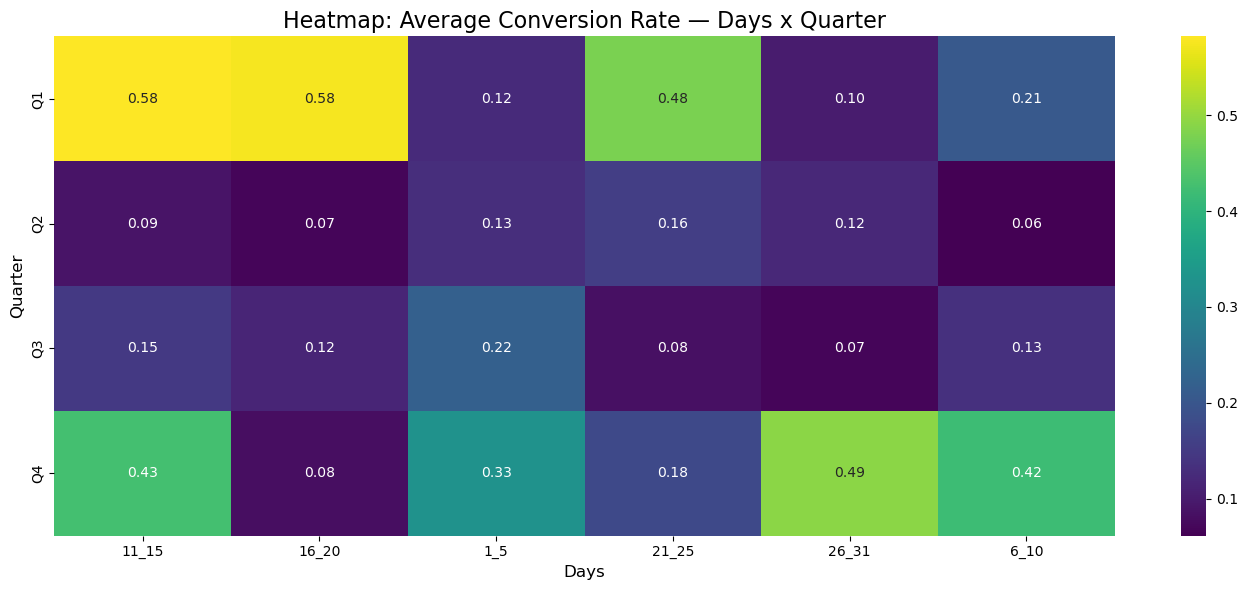

In [15]:
pivot = df_eda.pivot_table(
    values="y",
    index="quarter",         
    columns="days", 
    aggfunc="mean"
)

plt.figure(figsize=(14,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Heatmap: Average Conversion Rate — Days x Quarter", fontsize=16)
plt.xlabel("Days", fontsize=12)
plt.ylabel("Quarter", fontsize=12)
plt.tight_layout()
plt.show()

* Heatmap ocupação x educação (taxa média de conversão)

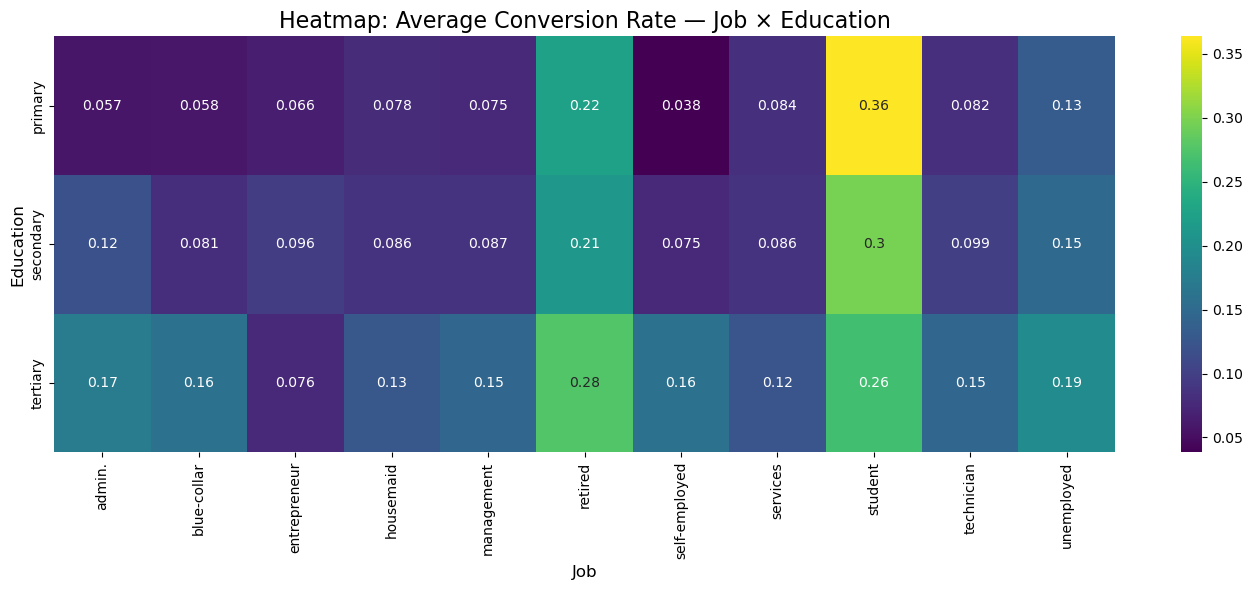

In [16]:
pivot = df_eda.pivot_table(
    values="y",
    index="education",
    columns="job",
    aggfunc="mean"
)

plt.figure(figsize=(14,6))
sns.heatmap(
    pivot,
    cmap="viridis",
    annot=True
)

plt.title("Heatmap: Average Conversion Rate — Job × Education", fontsize=16)
plt.xlabel("Job", fontsize=12)
plt.ylabel("Education", fontsize=12)
plt.tight_layout()
plt.show()

* Heatmap empréstimo habitacional x estado civil (taxa média de conversão)

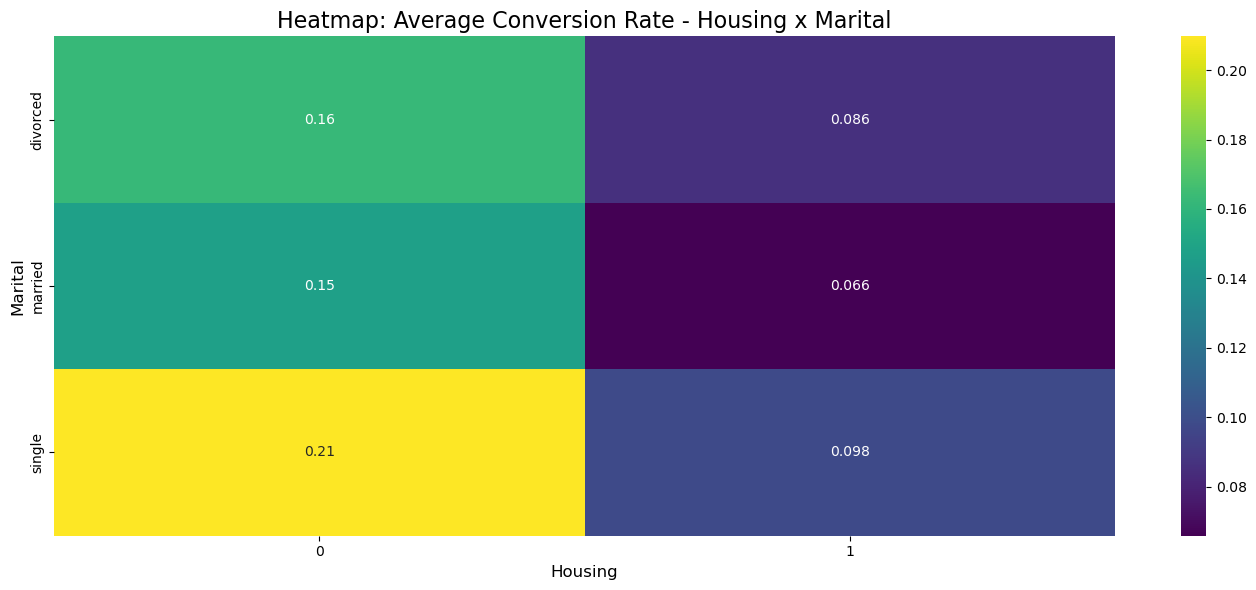

In [17]:
pivot = df_eda.pivot_table(
    values="y",
    index="marital",
    columns="housing",
    aggfunc="mean"
)

plt.figure(figsize=(14,6))
sns.heatmap(
    pivot,
    cmap="viridis",
    annot=True
)

plt.title("Heatmap: Average Conversion Rate - Housing x Marital", fontsize=16)
plt.xlabel("Housing", fontsize=12)
plt.ylabel("Marital", fontsize=12)
plt.tight_layout()
plt.show()

* Distribuição da variável target

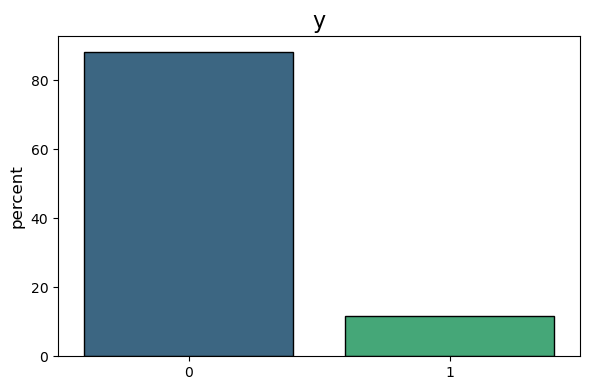

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df_eda,
    x="y",
    stat="percent",
    palette="viridis",
    edgecolor="black"
)
plt.title("y", fontsize=16)
plt.xlabel('',fontsize=12)
plt.ylabel("percent",fontsize=12)
plt.tight_layout()
plt.show();

* Distribuição das variáveis numéricas

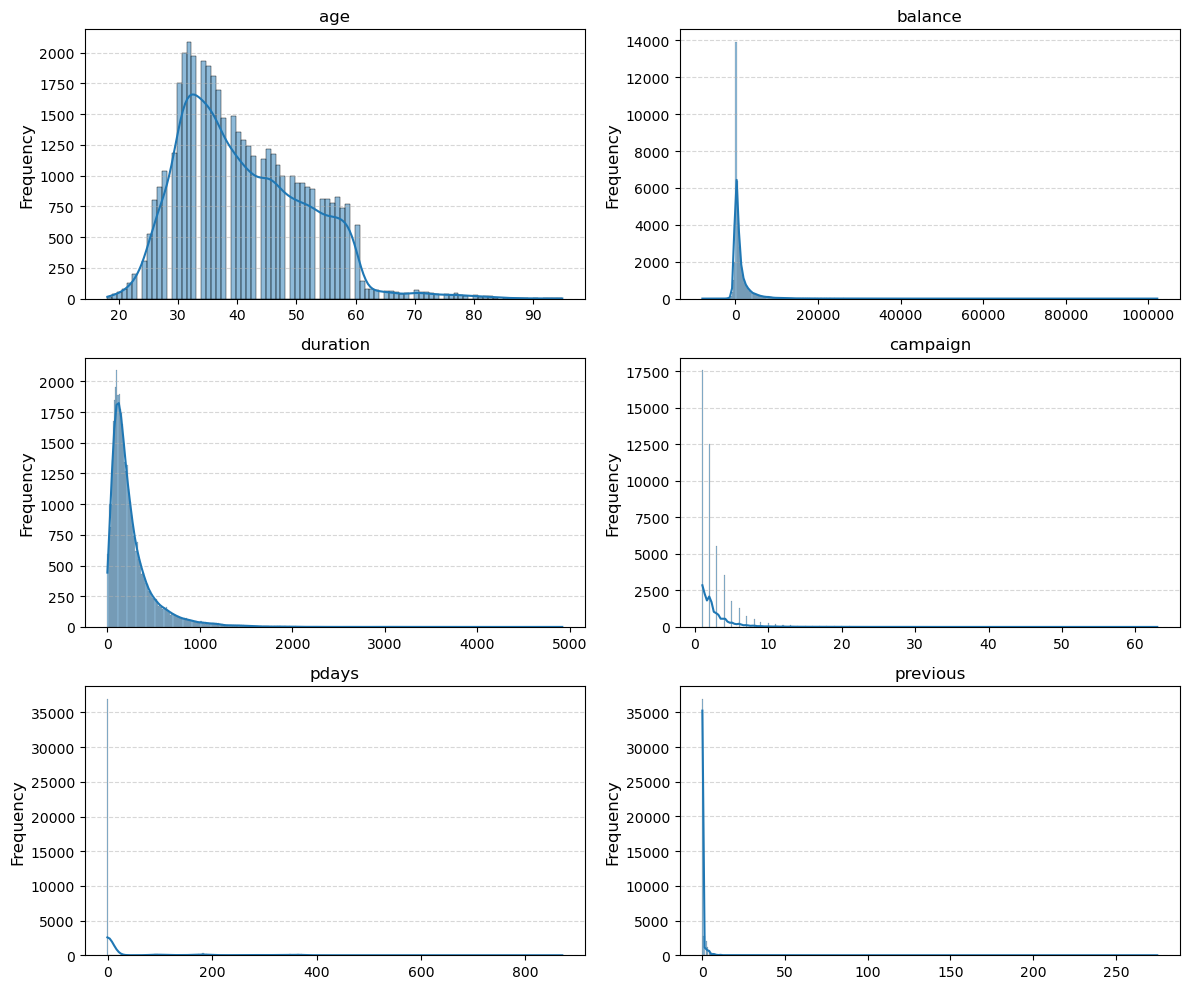

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols_num):
    sns.histplot(
        data=df_eda,
        x=col,
        kde=True,
        edgecolor="black",
        ax=ax
    )
    ax.set_title(col,fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel("Frequency", fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

# Caso tenha mais axes do que colunas 
for ax in axes[len(cols_num):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

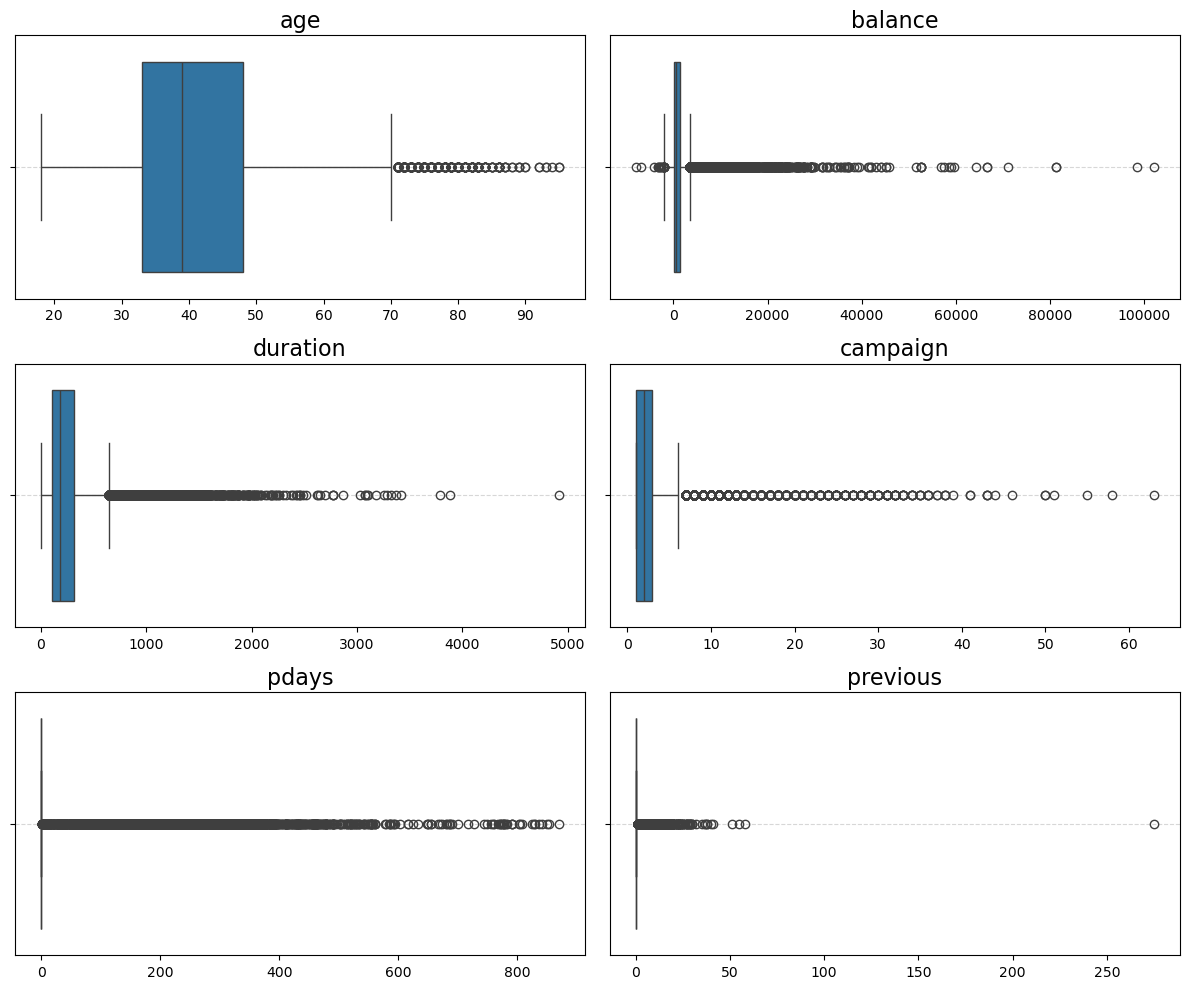

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols_num):
    sns.boxplot(
        data=df_eda,
        x=col,
        ax=ax
    )
    ax.set_title(col, fontsize=16)
    ax.set_xlabel('')
    ax.grid(axis="y", linestyle="--", alpha=0.5)

# Caso tenha mais axes do que colunas 
for ax in axes[len(cols_num):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Distribuição das variáveis binárias

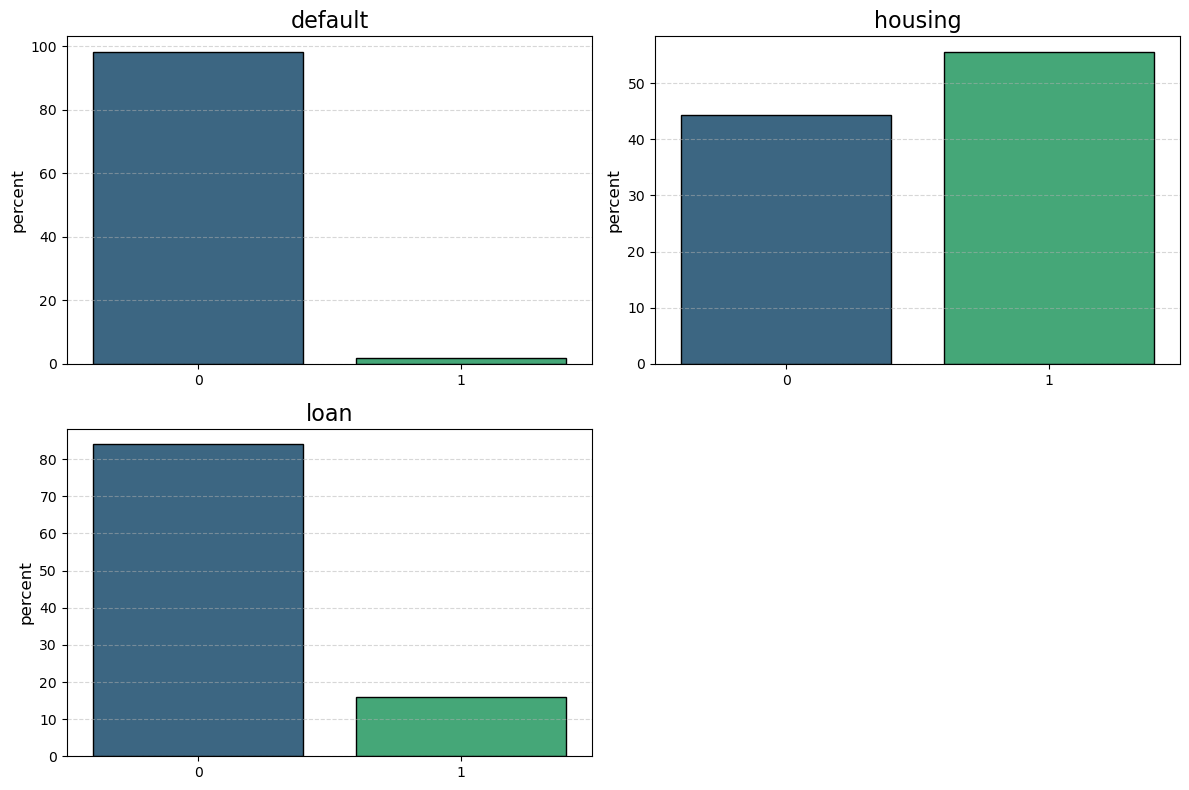

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols_bin):
    sns.countplot(
        data=df_eda,
        x=col,
        stat="percent",
        edgecolor="black",
        palette="viridis",
        ax=ax
    )
    ax.set_title(col, fontsize=16)
    ax.set_xlabel('')
    ax.set_ylabel('percent',fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

# Caso tenha mais axes do que colunas
for ax in axes[len(cols_bin):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Distribuição das variáveis categóricas

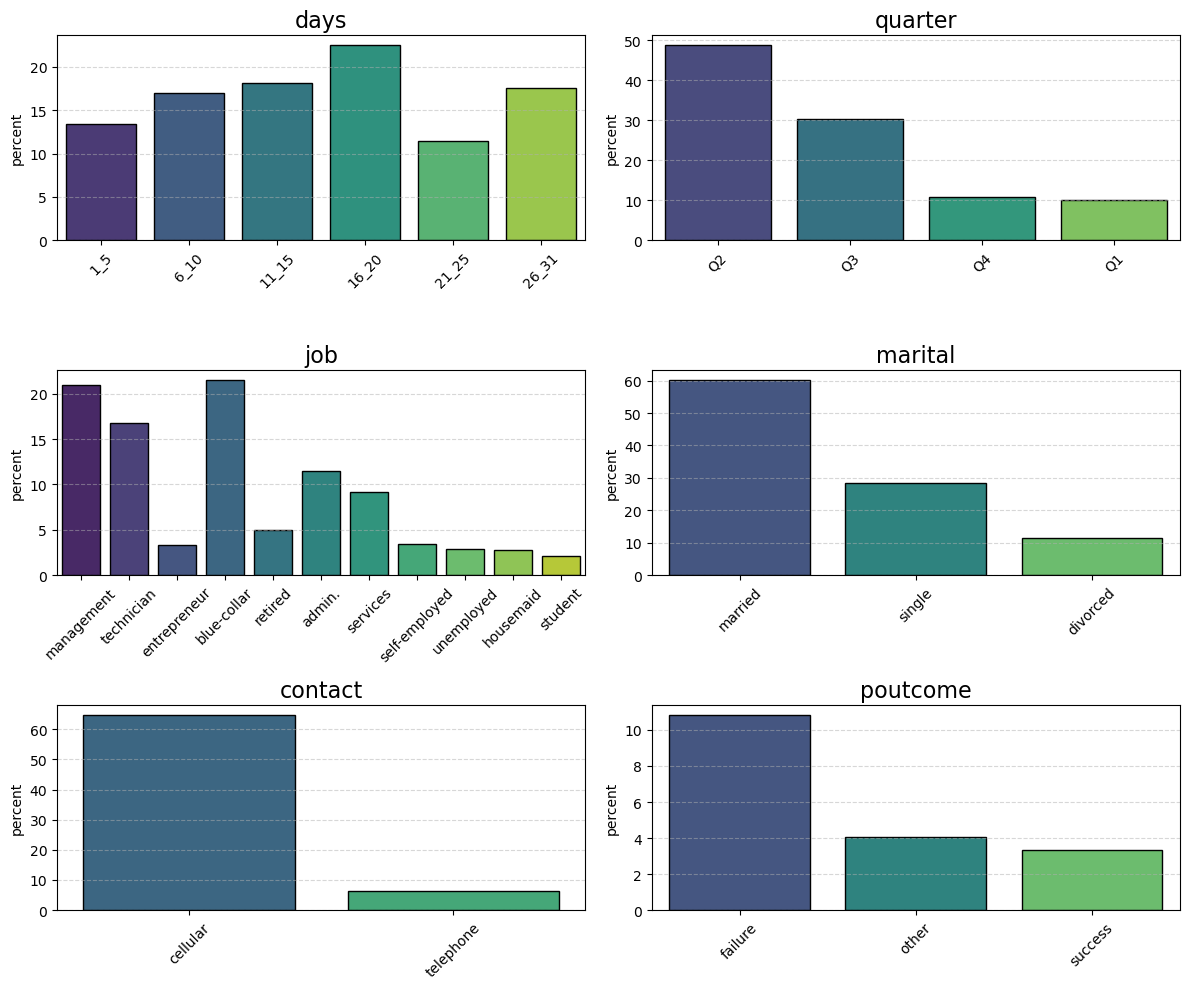

In [22]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols_cat):
    sns.countplot(
        data=df_eda,
        x=col,
        stat="percent",
        edgecolor="black",
        palette="viridis",
        ax=ax
    )
    ax.set_title(col,fontsize=16)
    ax.set_xlabel('')
    ax.set_ylabel("percent")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params("x", rotation=45)
    
# Caso tenha mais axes do que colunas
for ax in axes[len(cols_cat):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Distribuição da variável semi-ordinal

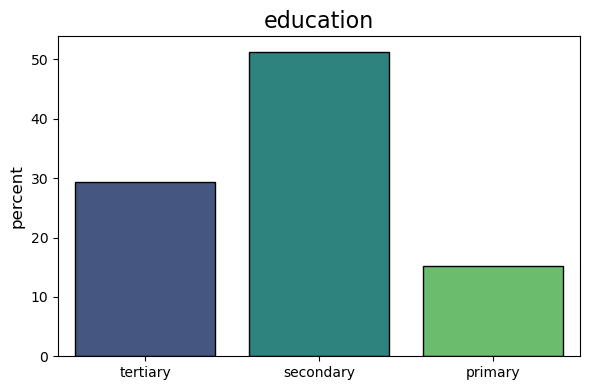

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=df_eda,
    x="education",
    stat="percent",
    edgecolor="black",
    palette="viridis"
)

plt.title("education", fontsize=16)
plt.xlabel('',fontsize=12)
plt.ylabel("percent", fontsize=12)
plt.tight_layout()
plt.show();

* Relação da variável target com as demais numéricas

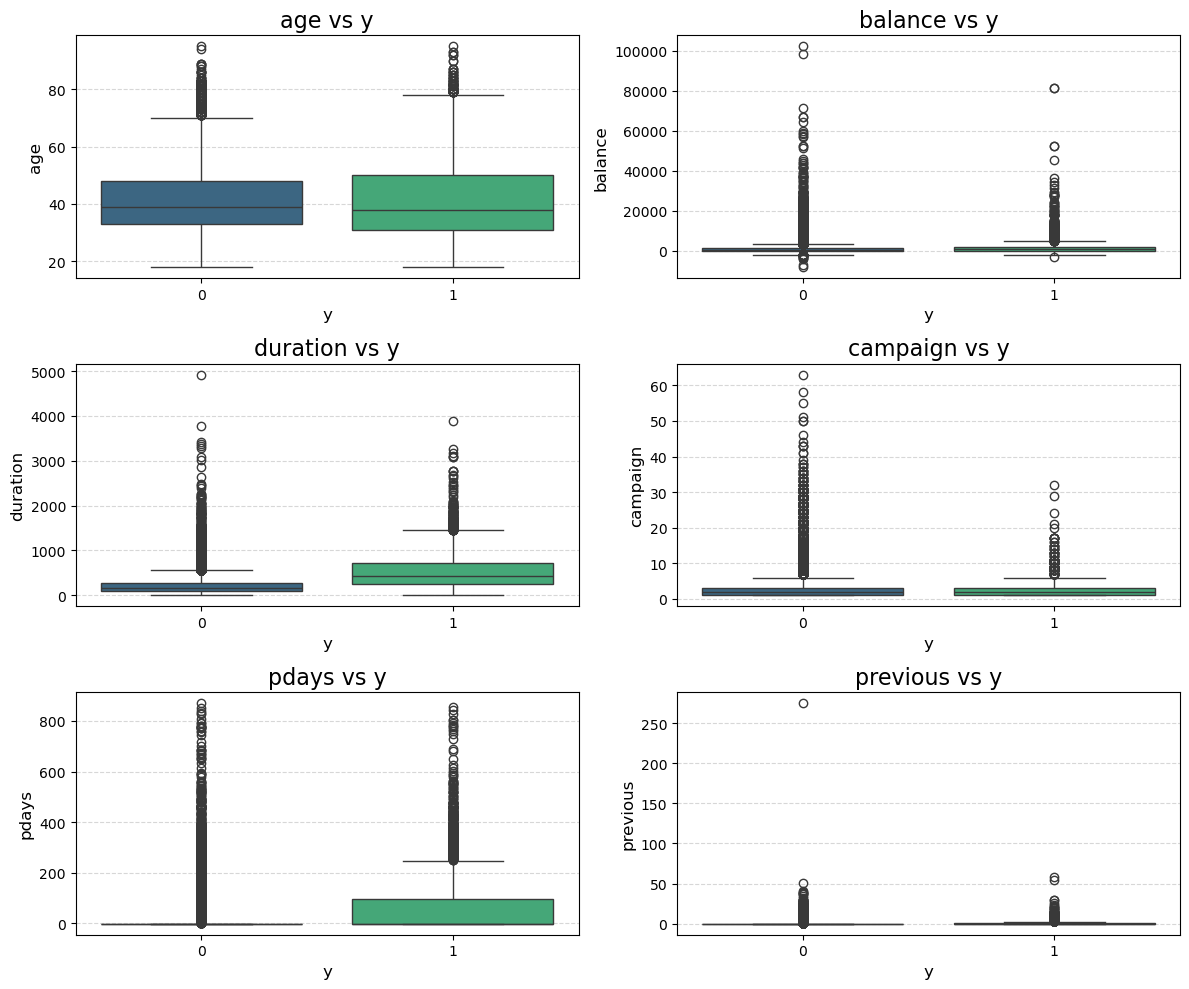

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols_num):
    sns.boxplot(
        data=df_eda,
        y=col,
        x="y",
        ax=ax,
        palette="viridis"
    )
    ax.set_title(f"{col} vs {target}", fontsize=16)
    ax.set_xlabel("y", fontsize=12)
    ax.set_ylabel(col, fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

# Caso tenha mais axes do que colunas numéricas
for ax in axes[len(cols_num):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Relação da variável target com as variáveis binárias

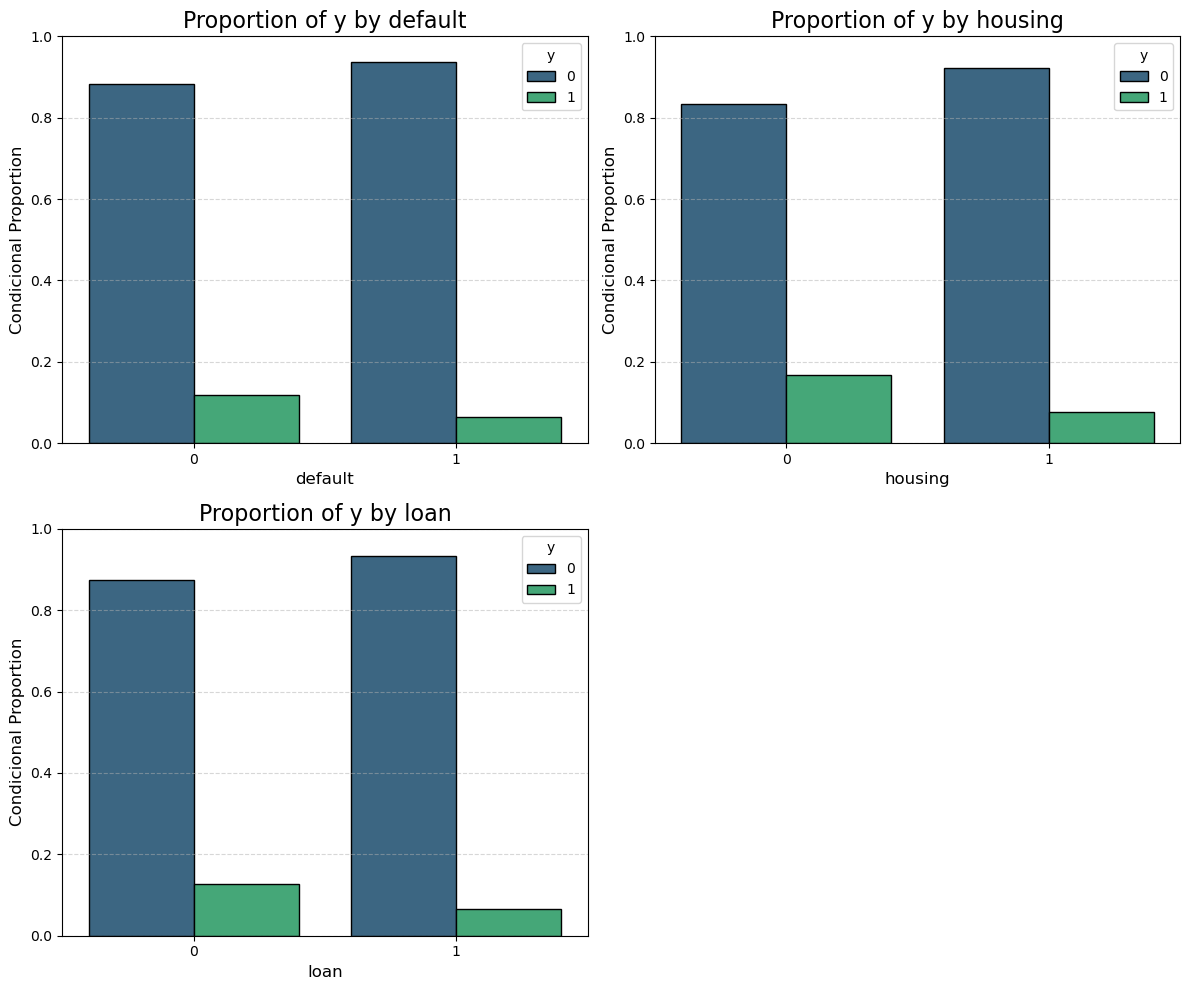

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols_bin):

    # Tabela de proporções condicionais
    prop = (
        df_eda
        .groupby(col)[target]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )

    sns.barplot(
        data=prop,
        x=col,
        y="proportion",
        hue=target,
        palette="viridis",
        ax=ax,
        edgecolor="black"
    )

    ax.set_title(f"Proportion of {target} by {col}", fontsize=16)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("Condicional Proportion", fontsize=12)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params("x")
    ax.tick_params("y")

# Remover axes excedentes
for ax in axes[len(cols_bin):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Relação da variável target com as variáveis categóricas

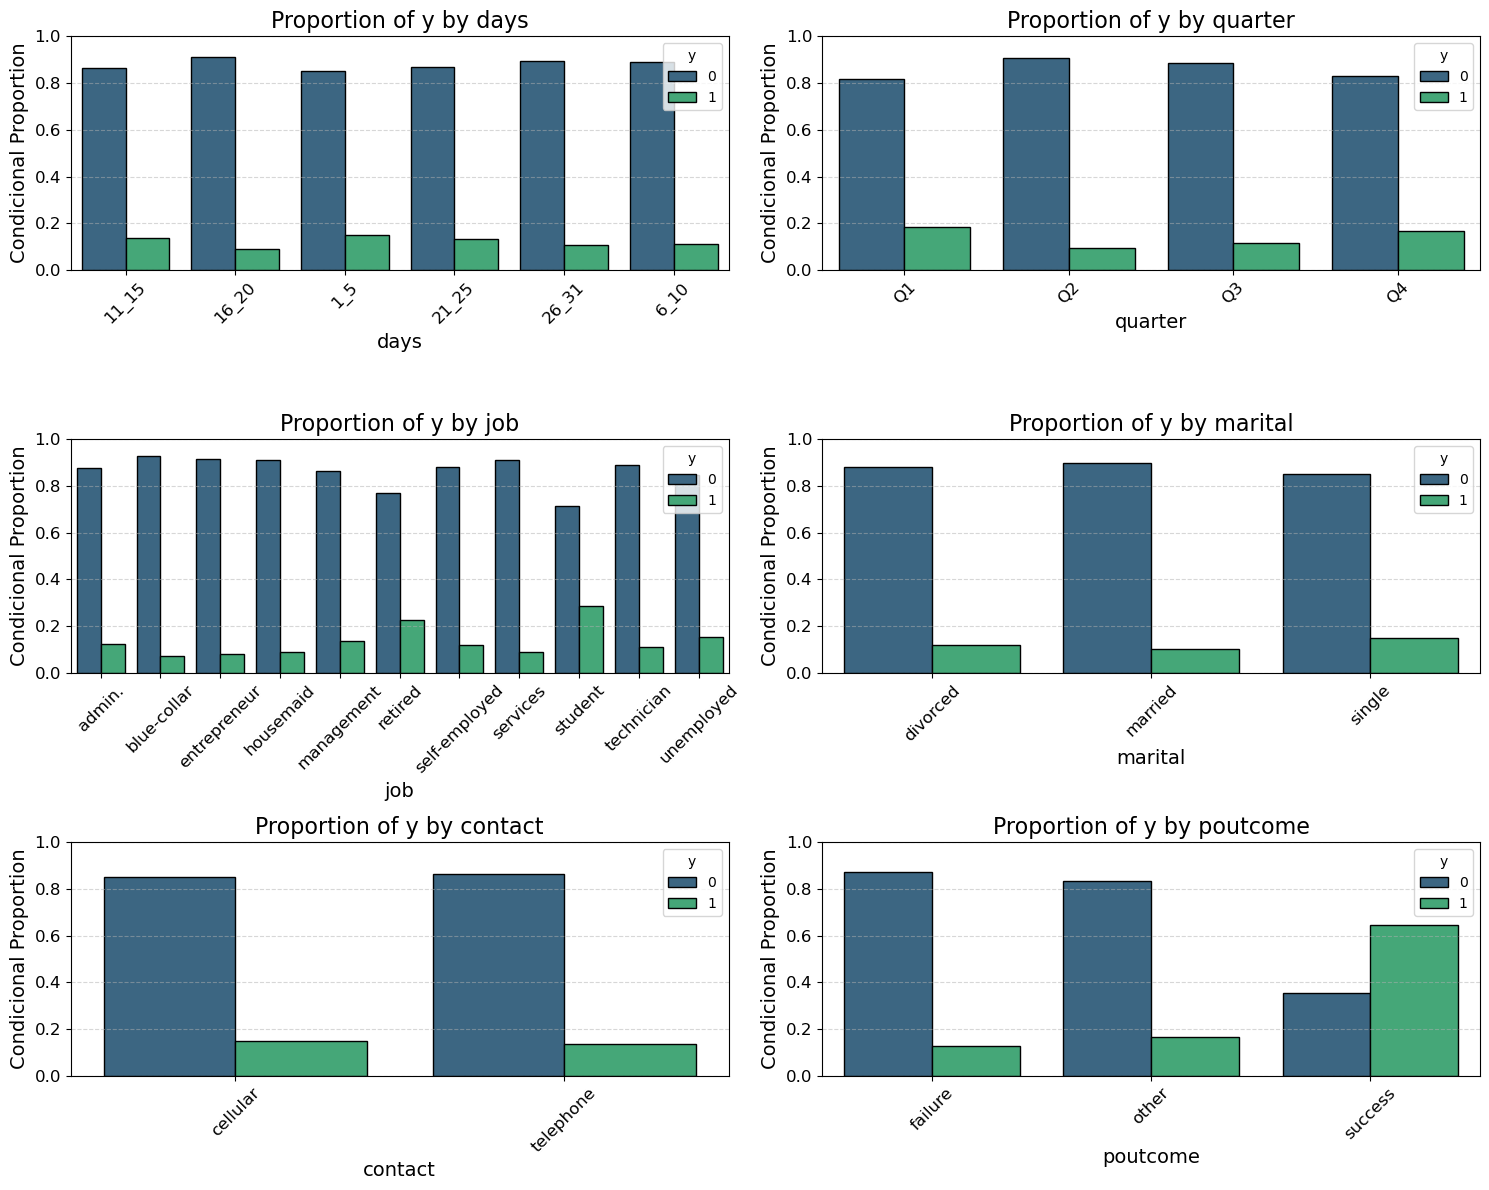

In [27]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols_cat):

    # Tabela de proporções condicionais
    prop = (
        df_eda
        .groupby(col)[target]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )

    sns.barplot(
        data=prop,
        x=col,
        y="proportion",
        hue=target,
        palette="viridis",
        ax=ax,
        edgecolor="black"
    )

    ax.set_title(f"Proportion of {target} by {col}", fontsize=16)
    ax.set_xlabel(col, fontsize=14)
    ax.set_ylabel("Condicional Proportion", fontsize=14)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params("x", rotation=45, labelsize=12)
    ax.tick_params("y",labelsize=12)

# Remover axes excedentes
for ax in axes[len(cols_cat):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

* Relação da variável target com a variável semi-ordinária

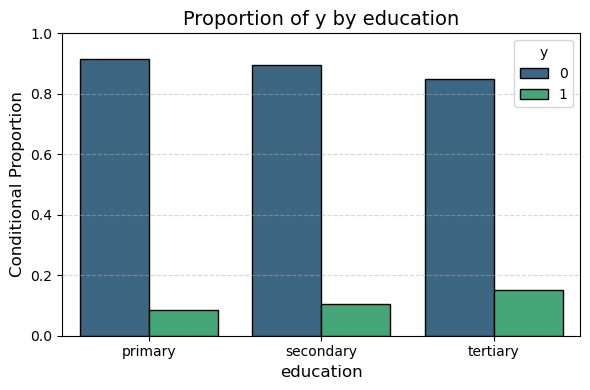

In [28]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4)) 

if not isinstance(axes, np.ndarray):
    axes = [axes]

for ax, col in zip(axes, cols_semiord):

    # Tabela de proporções condicionais
    prop = (
        df_eda
        .groupby(col)[target]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )

    sns.barplot(
        data=prop,
        x=col,
        y="proportion",
        hue=target,
        palette="viridis",
        ax=ax,
        edgecolor="black"
    )

    ax.set_title(f"Proportion of {target} by {col}", fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("Conditional Proportion", fontsize=12)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params("x", labelsize=10)

if len(axes) > len(cols_semiord):
    for i in range(len(cols_semiord), len(axes)):
        fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

* Correlação 

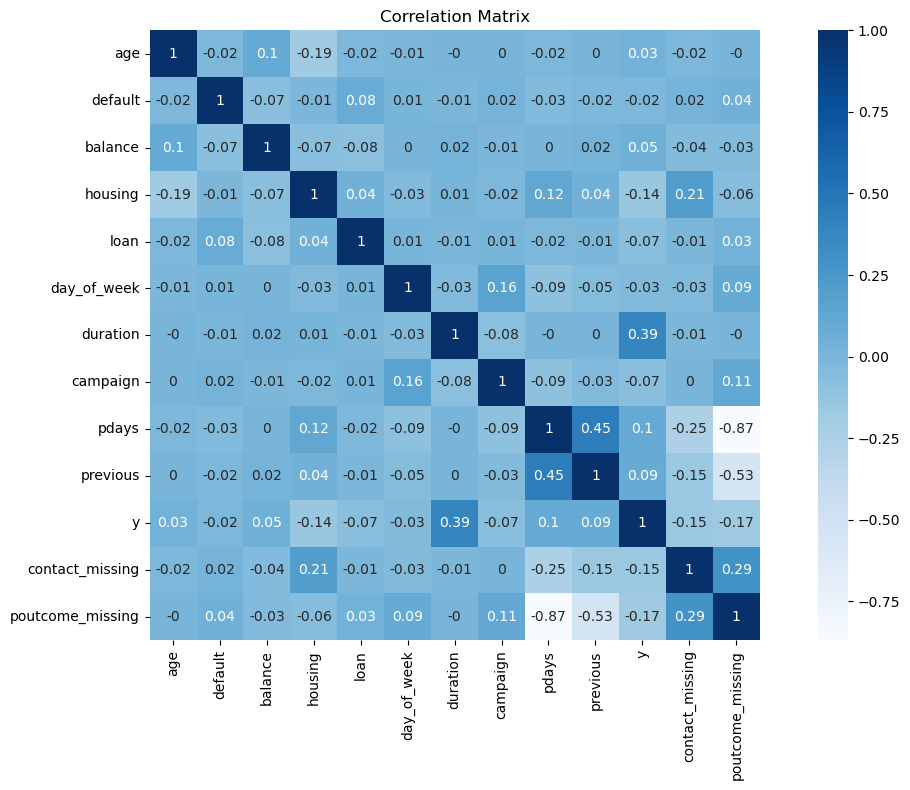

In [29]:
plt.figure(figsize = (12,8))
plt.title("Correlation Matrix")

corr = df_eda.corr(numeric_only = True)
sns.heatmap(corr.round(2), vmax = 1, square = True, annot = True, cmap = "Blues")

plt.tight_layout()
plt.show()

* Associação

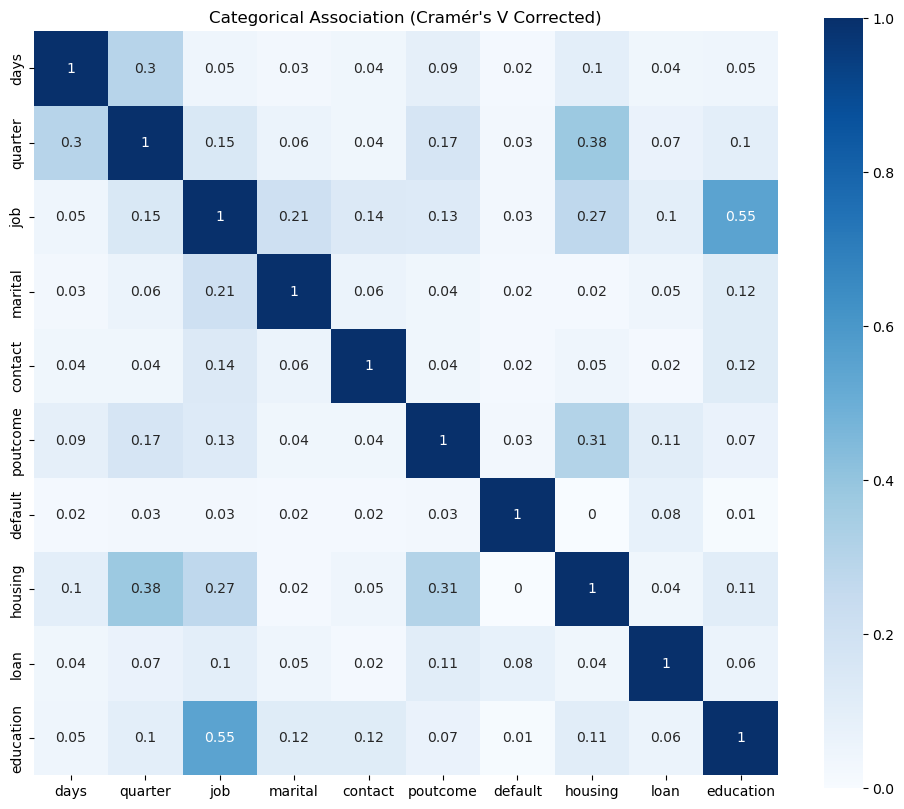

In [30]:
def cramers_v_corrected(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    phi2corr = max(0, phi2 - ((k - 1)*(r - 1))/(n - 1))
    rcorr = r - (r - 1)**2 / (n - 1)
    kcorr = k - (k - 1)**2 / (n - 1)

    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

cols_v = cols_cat + cols_bin + cols_semiord 

mat = pd.DataFrame(index=cols_v, columns=cols_v)

for c1 in cols_v:
    for c2 in cols_v:
        tab = pd.crosstab(df_eda[c1], df_eda[c2])
        mat.loc[c1, c2] = cramers_v_corrected(tab.values)

plt.figure(figsize=(12,10))
sns.heatmap(mat.astype(float).round(2), annot=True, square=True, cmap='Blues', vmin=0, vmax=1)
plt.title("Categorical Association (Cramér's V Corrected)")
plt.show()

* Data leakage

In [31]:
leakage_features = []


def leakage_mi_permutation_test(
    df,
    feature,
    target="y",
    n_permutations=20,
    random_state=42
):
    # Checagem mínima
    if feature not in df.columns or target not in df.columns:
        raise ValueError("Feature ou target inexistente.")

    df_local = df[[feature, target]].dropna()

    X = df_local[[feature]]
    y = df_local[target]

    # MI real
    mi_real = mutual_info_classif(
        X, y,
        discrete_features="auto",
        random_state=random_state
    )[0]

    # MI sob permutação do target
    rng = np.random.RandomState(random_state)
    mi_perm = []

    for _ in range(n_permutations):
        y_perm = rng.permutation(y)
        mi_p = mutual_info_classif(
            X, y_perm,
            discrete_features="auto",
            random_state=random_state
        )[0]
        mi_perm.append(mi_p)

    mi_perm = np.array(mi_perm)

    delta = mi_real - mi_perm.mean()
    z_score = delta / (mi_perm.std() + 1e-8)

    return {
        "feature": feature,
        "mi_real": mi_real,
        "mi_perm_mean": mi_perm.mean(),
        "delta_mi": delta,
        "z_score": z_score
    }


In [32]:
result = leakage_mi_permutation_test(df_eda, feature="duration") # feature = variável suspeita

if result["z_score"] > 5:
    leakage_features.append("duration")
    
print(f"Feature causing leakage: {leakage_features}")

Feature causing leakage: ['duration']


In [33]:
result = leakage_mi_permutation_test(df_eda, feature="contact_missing") # feature = variável suspeita

if result["z_score"] > 5:
    leakage_features.append("contact_missing")
    
print(f"Feature causing leakage: {leakage_features}")

Feature causing leakage: ['duration', 'contact_missing']


In [34]:
result = leakage_mi_permutation_test(df_eda, feature="poutcome_missing") # feature = variável suspeita

if result["z_score"] > 5:
    leakage_features.append("poutcome_missing")
    
print(f"Feature causing leakage: {leakage_features}")

Feature causing leakage: ['duration', 'contact_missing', 'poutcome_missing']


# Pré-processamento

* Dataset de pré-processamento

In [35]:
df_prep = df_eda.copy()

* Tratamento de valores duplicados e valores faltantes

In [36]:
imputer_semior = SimpleImputer(strategy="most_frequent")   # education
imputer_nominal = SimpleImputer(strategy="most_frequent")  # job

* Remoção de features

In [37]:
df_prep = df_prep.drop(columns = ["day_of_week", "month", "duration", 
                                  "contact", "poutcome",
                                  "contact_missing", "poutcome_missing"]).reset_index(drop=True)

* Pré-processador

In [38]:
cols_num = ["age", "balance", "campaign", "pdays", "previous"]   

cols_bin = ["default", "housing", "loan"]   

cols_cat = ["days", "quarter", "job", "marital"]

cols_semiord = ["education"]  

target = "y"   

In [39]:
encoder_nominal = OneHotEncoder(drop="first", handle_unknown="ignore")

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        # Numéricas — padronizadas para TODOS os modelos
        ("num", StandardScaler(), cols_num),

        # Binárias — já numéricas, sem imputação
        ("bin", "passthrough", cols_bin),

        # Semi-ordinal
        ("semior", Pipeline(steps=[
            ("imputer", imputer_semior),
            ("onehot", encoder_nominal)
        ]), cols_semiord),

        # Categóricas nominais
        ("cat", Pipeline(steps=[
            ("imputer", imputer_nominal),
            ("onehot", encoder_nominal)
        ]), cols_cat),
    ],
    remainder="drop"
)

* Separar X e Y

In [41]:
X = df_prep.drop(columns = ["y"])
y = df_prep["y"]

* Dividir em treino/teste (antes de fit)

In [42]:
# Stratify em y é essencial para um dataset desbalanceado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Treinamento e Avaliação de Modelos Base

* Criar avaliador universal

In [43]:
# ============================================================
# Avaliador 
# ============================================================

def evaluate_model(
    name,
    pipeline,
    X_test,
    y_test,
    ks=(0.01, 0.05),
    plot_confusion=True
):
    """
    Avaliador universal para Bank Marketing (subscrição de depósito).

    Objetivo REAL:
    - Priorizar clientes com maior probabilidade de conversão
    - Avaliação baseada em ranking (não em threshold fixo)

    Notas importantes:
    - Threshold 0.5 é APENAS diagnóstico
    - Comparação de modelos deve usar métricas threshold-independentes
      e métricas de ranking (Precision@K / Lift@K)
    """

    print(f"\n{'='*65}")
    print(f"MODEL: {name}")
    print(f"{'='*65}")

    # --------------------------------------------------------
    # 1. Probabilidades previstas
    # --------------------------------------------------------
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # --------------------------------------------------------
    # 2. Métricas globais (threshold-independentes)
    # --------------------------------------------------------
    roc_auc = roc_auc_score(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)

    print("\nGLOBAL METRICS:")
    print(f"  ROC-AUC:           {roc_auc:.4f}")
    print(f"  Average Precision: {ap:.6f}")

    # --------------------------------------------------------
    # 3. Métricas de ranking (marketing direto)
    # --------------------------------------------------------
    base_rate = y_test.mean()

    print("\nRANKING METRICS (CAMPAIGN TRIAGE):")
    print(f"  Base conversion rate: {base_rate:.4f}")

    n = len(y_proba)

    for k in ks:
        cutoff = int(n * k)
        idx = np.argsort(y_proba)[::-1][:cutoff]

        # Taxa de conversão no Top-K (Precision@K)
        precision_k = y_test.iloc[idx].mean()

        # Lift relativo ao contato aleatório
        lift_k = precision_k / base_rate if base_rate > 0 else np.nan

        print(f"\n  Top {int(k * 100)}% clients:")
        print(f"    Conversion Rate (Precision@K): {precision_k:.4f}")
        print(f"    Lift@K:                        {lift_k:.2f}")

    # --------------------------------------------------------
    # 4. Diagnóstico com threshold fixo (0.50)
    # --------------------------------------------------------
    y_pred = (y_proba >= 0.5).astype(int)

    print("\nDIAGNOSTIC REPORT (Threshold = 0.50):")
    print(classification_report(y_test, y_pred, digits=4))

    if plot_confusion:
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_pred,
            ax=ax,
            cmap="Blues",
            values_format="d"
        )
        plt.title(f"Confusion Matrix – {name}")
        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # 5. Retorno estruturado
    # --------------------------------------------------------
    return {
        "Model": name,
        "ROC AUC": roc_auc,
        "Average Precision": ap,
        "Base Rate": base_rate,
        "Y Proba": y_proba
    }

* Pipeline final para cada modelo

In [44]:
y_train_num = y_train.astype(int)
y_test_num  = y_test.astype(int)

scale_pos_weight = (y_train_num == 0).sum() / (y_train_num == 1).sum()


MODEL: Baseline – Most Frequent

GLOBAL METRICS:
  ROC-AUC:           0.5000
  Average Precision: 0.116997

RANKING METRICS (CAMPAIGN TRIAGE):
  Base conversion rate: 0.1170

  Top 1% clients:
    Conversion Rate (Precision@K): 0.0889
    Lift@K:                        0.76

  Top 5% clients:
    Conversion Rate (Precision@K): 0.0929
    Lift@K:                        0.79

DIAGNOSTIC REPORT (Threshold = 0.50):
              precision    recall  f1-score   support

           0     0.8830    1.0000    0.9379      7985
           1     0.0000    0.0000    0.0000      1058

    accuracy                         0.8830      9043
   macro avg     0.4415    0.5000    0.4689      9043
weighted avg     0.7797    0.8830    0.8281      9043



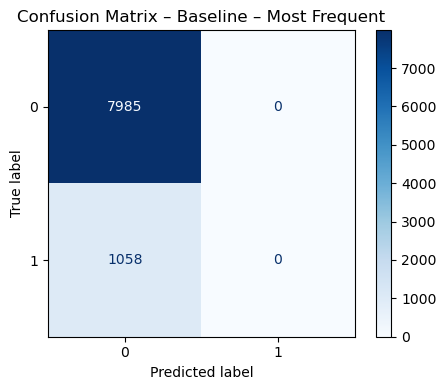


MODEL: Baseline – Stratified

GLOBAL METRICS:
  ROC-AUC:           0.4970
  Average Precision: 0.116415

RANKING METRICS (CAMPAIGN TRIAGE):
  Base conversion rate: 0.1170

  Top 1% clients:
    Conversion Rate (Precision@K): 0.1000
    Lift@K:                        0.85

  Top 5% clients:
    Conversion Rate (Precision@K): 0.1084
    Lift@K:                        0.93

DIAGNOSTIC REPORT (Threshold = 0.50):
              precision    recall  f1-score   support

           0     0.8823    0.8873    0.8848      7985
           1     0.1115    0.1068    0.1091      1058

    accuracy                         0.7960      9043
   macro avg     0.4969    0.4970    0.4970      9043
weighted avg     0.7921    0.7960    0.7940      9043



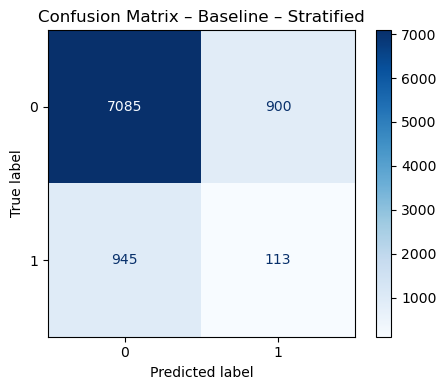


MODEL: Logistic Regression

GLOBAL METRICS:
  ROC-AUC:           0.7167
  Average Precision: 0.264733

RANKING METRICS (CAMPAIGN TRIAGE):
  Base conversion rate: 0.1170

  Top 1% clients:
    Conversion Rate (Precision@K): 0.4222
    Lift@K:                        3.61

  Top 5% clients:
    Conversion Rate (Precision@K): 0.3717
    Lift@K:                        3.18

DIAGNOSTIC REPORT (Threshold = 0.50):
              precision    recall  f1-score   support

           0     0.9363    0.6624    0.7759      7985
           1     0.2057    0.6597    0.3136      1058

    accuracy                         0.6621      9043
   macro avg     0.5710    0.6611    0.5447      9043
weighted avg     0.8508    0.6621    0.7218      9043



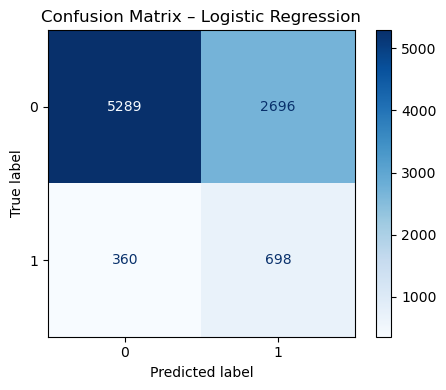


MODEL: Random Forest

GLOBAL METRICS:
  ROC-AUC:           0.7411
  Average Precision: 0.331636

RANKING METRICS (CAMPAIGN TRIAGE):
  Base conversion rate: 0.1170

  Top 1% clients:
    Conversion Rate (Precision@K): 0.5667
    Lift@K:                        4.84

  Top 5% clients:
    Conversion Rate (Precision@K): 0.4801
    Lift@K:                        4.10

DIAGNOSTIC REPORT (Threshold = 0.50):
              precision    recall  f1-score   support

           0     0.8950    0.9852    0.9379      7985
           1     0.5336    0.1276    0.2059      1058

    accuracy                         0.8849      9043
   macro avg     0.7143    0.5564    0.5719      9043
weighted avg     0.8527    0.8849    0.8523      9043



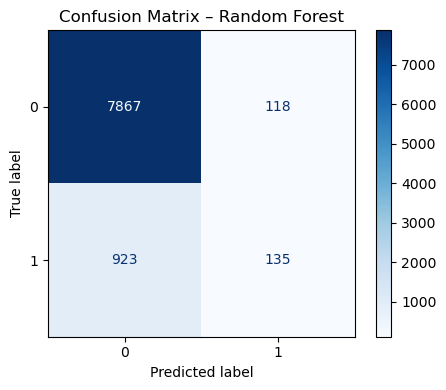


MODEL: XGBoost

GLOBAL METRICS:
  ROC-AUC:           0.7376
  Average Precision: 0.353649

RANKING METRICS (CAMPAIGN TRIAGE):
  Base conversion rate: 0.1170

  Top 1% clients:
    Conversion Rate (Precision@K): 0.6333
    Lift@K:                        5.41

  Top 5% clients:
    Conversion Rate (Precision@K): 0.5221
    Lift@K:                        4.46

DIAGNOSTIC REPORT (Threshold = 0.50):
              precision    recall  f1-score   support

           0     0.9327    0.8302    0.8785      7985
           1     0.2996    0.5482    0.3874      1058

    accuracy                         0.7972      9043
   macro avg     0.6162    0.6892    0.6330      9043
weighted avg     0.8587    0.7972    0.8210      9043



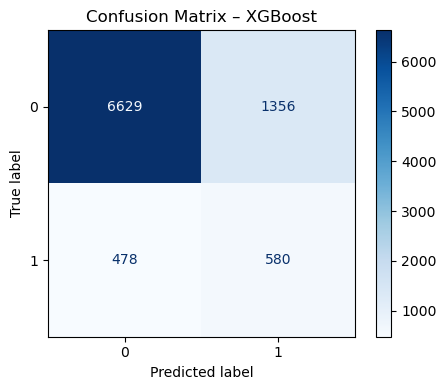

[LightGBM] [Info] Number of positive: 4231, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001858 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 709
[LightGBM] [Info] Number of data points in the train set: 36168, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116982 -> initscore=-2.021327
[LightGBM] [Info] Start training from score -2.021327

MODEL: LightGBM

GLOBAL METRICS:
  ROC-AUC:           0.7597
  Average Precision: 0.378898

RANKING METRICS (CAMPAIGN TRIAGE):
  Base conversion rate: 0.1170

  Top 1% clients:
    Conversion Rate (Precision@K): 0.6778
    Lift@K:                        5.79

  Top 5% clients:
    Conversion Rate (Precision@K): 0.5398
    Lift@K:                        4.61

DIAGNOSTIC REPORT (Threshold = 0.50):
              precision    recall  f1-score 

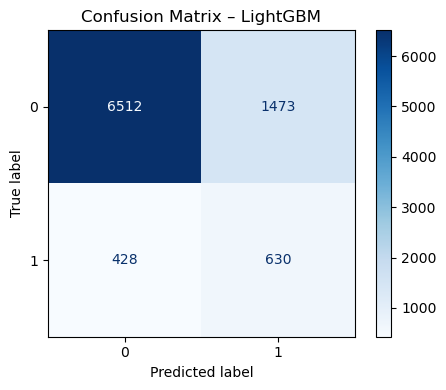

{'Model': 'LightGBM',
 'ROC AUC': 0.7596611912932212,
 'Average Precision': 0.37889785327541337,
 'Base Rate': np.float64(0.11699657193409267),
 'Y Proba': array([0.21963534, 0.19363587, 0.25804673, ..., 0.37010323, 0.83591943,
        0.23801287], shape=(9043,))}

In [45]:
# Dummy – Mais frequente (lower bound)
dummy_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent", random_state=42))
])

dummy_pipe.fit(X_train, y_train_num)
evaluate_model("Baseline – Most Frequent", dummy_pipe, X_test, y_test_num)

dummy_strat = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy="stratified", random_state=42))
])

# Dummy – Stratified (baseline probabilístico)
dummy_strat.fit(X_train, y_train_num)
evaluate_model("Baseline – Stratified", dummy_strat, X_test, y_test_num)

# Regressão Logística
logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_pipe.fit(X_train, y_train_num)
evaluate_model("Logistic Regression", logreg_pipe, X_test, y_test_num)

# Random Forest
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train_num)
evaluate_model("Random Forest", rf_pipe, X_test, y_test_num)

# XGBoost
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        verbosity=0,
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_train, y_train_num)
evaluate_model("XGBoost", xgb_pipe, X_test, y_test_num)

# LGBM
lgbm_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

lgbm_pipe.fit(X_train, y_train_num)
evaluate_model("LightGBM", lgbm_pipe, X_test, y_test_num)

* Resultados

In [47]:
def get_metrics_bank(
    model,
    X_test,
    y_test,
    ks=(0.01, 0.05)
):
    """
    Avaliação para COMPETIÇÃO DE MODELOS – BANK MARKETING

    - NÃO usa threshold fixo
    - Baseada em ranking probabilístico
    - Otimizada para priorização de contatos
    """

    # --------------------------------------------------
    # Probabilidades da classe positiva (subscrição)
    # --------------------------------------------------
    y_proba = model.predict_proba(X_test)[:, 1]

    # --------------------------------------------------
    # Métricas globais (threshold-independente)
    # --------------------------------------------------
    ap = average_precision_score(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    metrics = {
        "AP": ap,
        "ROC_AUC": auc
    }

    # --------------------------------------------------
    # Métricas de ranking (campanha)
    # --------------------------------------------------
    base_rate = y_test.mean()
    order = np.argsort(y_proba)[::-1]

    n = len(y_test)

    for k in ks:
        cutoff = int(n * k)
        top_k_idx = order[:cutoff]

        # Taxa de conversão no Top-K
        precision_k = y_test.iloc[top_k_idx].mean()

        # Lift relativo ao contato aleatório
        lift_k = precision_k / base_rate if base_rate > 0 else np.nan

        metrics[f"Conversion@{int(k*100)}%"] = precision_k
        metrics[f"Lift@{int(k*100)}%"] = lift_k

    return metrics

In [48]:
results = []

models = {
    "Dummy – Most Frequent": dummy_pipe,
    "Dummy – Stratified": dummy_strat,
    "Logistic Regression": logreg_pipe,
    "Random Forest": rf_pipe,
    "XGBoost": xgb_pipe,
    "LGBM": lgbm_pipe
}

for name, model in models.items():
    metrics = get_metrics_bank(
        model,
        X_test,
        y_test_num,
        ks=(0.01, 0.05)
    )

    results.append([
        name,
        metrics["AP"],
        metrics["ROC_AUC"],
        metrics["Conversion@1%"],
        metrics["Lift@1%"],
        metrics["Conversion@5%"],
        metrics["Lift@5%"]
    ])

df_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Avg Precision",
        "ROC-AUC",
        "Conversion @ 1%",
        "Lift @ 1%",
        "Conversion @ 5%",
        "Lift @ 5%"
    ]
)

df_results.sort_values("Avg Precision", ascending=False, inplace=True)
df_results

,Model,Avg Precision,ROC-AUC,Conversion @ 1%,Lift @ 1%,Conversion @ 5%,Lift @ 5%
5,LGBM,0.378898,0.759661,0.677778,5.793142,0.539823,4.614007
4,XGBoost,0.353649,0.737586,0.633333,5.413264,0.522124,4.462728
3,Random Forest,0.331636,0.741053,0.566667,4.843447,0.480088,4.103441
2,Logistic Regression,0.264733,0.716660,0.422222,3.608843,0.371681,3.176857
0,Dummy – Most Frequent,0.116997,0.500000,0.088889,0.759756,0.092920,0.794214
1,Dummy – Stratified,0.116415,0.497047,0.100000,0.854726,0.108407,0.926583


# Modelos Promissores

In [49]:
# Criar um diretório temporário para cache
cachedir = mkdtemp()

* LGBM

In [50]:
lgbm_param_grid = {
    "model__max_depth": [3, 5, 7, 10, -1],   # -1 = sem limite
    "model__num_leaves": [15, 31, 63, 127],  # compatível com max_depth
    "model__min_child_samples": [10, 20, 50, 100],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0]
}

lgbm_pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LGBMClassifier(
            objective="binary",
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ))
    ],
    memory=cachedir
)

grid_lgbm = HalvingRandomSearchCV(
    estimator=lgbm_pipe,
    param_distributions=lgbm_param_grid,
    factor=3,
    resource="model__n_estimators",
    min_resources=100,
    max_resources=600,
    scoring="average_precision",
    cv=5,
    random_state=42,
    n_jobs=-1
)

print("Starting Search LightGBM...")
grid_lgbm.fit(X_train, y_train_num)

Starting Search LightGBM...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(memo...verbose=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__min_child_samples': [10, 20, ...], ...}"
,"n_candidates n_candidates: ""exhaust"" or int, default=""exhaust""The number of candidate parameters to sample, at the firstiteration. Using 'exhaust' will sample enough candidates so that thelast iteration uses as many resources as possible, based on`min_resources`, `max_resources` and `factor`. In this case,`min_resources` cannot be 'exhaust'.",'exhaust'
,"factor factor: int or float, default=3The 'halving' parameter, which determines the proportion of candidatesthat are selected for each subsequent iteration. For example,``factor=3`` means that only one third of the candidates are selected.",3
,"resource resource: ``'n_samples'`` or str, default='n_samples'Defines the resource that increases with each iteration. By default,the resource is the number of samples. It can also be set to anyparameter of the base estimator that accepts positive integervalues, e.g. 'n_iterations' or 'n_estimators' for a gradientboosting estimator. In this case ``max_resources`` cannot be 'auto'and must be set explicitly.",'model__n_estimators'
,"max_resources max_resources: int, default='auto'The maximum number of resources that any candidate is allowed to usefor a given iteration. By default, this is set ``n_samples`` when``resource='n_samples'`` (default), else an error is raised.",600
,"min_resources min_resources: {'exhaust', 'smallest'} or int, default='smallest'The minimum amount of resource that any candidate is allowed to usefor a given iteration. Equivalently, this defines the amount ofresources `r0` that are allocated for each candidate at the firstiteration.- 'smallest' is a heuristic that sets `r0` to a small value: - ``n_splits * 2`` when ``resource='n_samples'`` for a regression problem - ``n_classes * n_splits * 2`` when ``resource='n_samples'`` for a classification problem - ``1`` when ``resource != 'n_samples'``- 'exhaust' will set `r0` such that the **last** iteration uses as much resources as possible. Namely, the last iteration will use the highest value smaller than ``max_resources`` that is a multiple of both ``min_resources`` and ``factor``. In general, using 'exhaust' leads to a more accurate estimator, but is slightly more time consuming. 'exhaust' isn't available when `n_candidates='exhaust'`.Note that the amount of resources used at each iteration is always amultiple of ``min_resources``.",100
,"aggressive_elimination aggressive_elimination: bool, default=FalseThis is only relevant in cases where there isn't enough resources toreduce the remaining candidates to at most `factor` after the lastiteration. If ``True``, then the search process will 'replay' thefirst iteration for as long as needed until the number of candidatesis small enough. This is ``False`` by default, which means that thelast iteration may evaluate more than ``factor`` candidates. See:ref:`aggressive_elimination` for more details.",False
,"cv cv: int, cross-validation generator or an iterable, default=5Determines the cross-validation splitting strategy.Possible inputs for cv are:- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/No

* XGBoost

In [51]:
xgb_param_grid = {
    "model__max_depth": [3, 5, 7, 10],
    "model__min_child_weight": [1, 5, 10, 20],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0]
}

xgb_pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            verbosity=0,
            n_jobs=-1
        ))
    ],
    memory=cachedir
)

grid_xgb = HalvingRandomSearchCV(
    estimator=xgb_pipe,
    param_distributions=xgb_param_grid,
    factor=3,
    resource="model__n_estimators",
    min_resources=100,
    max_resources=600,
    scoring="average_precision",
    cv=5,
    random_state=42,
    n_jobs=-1
)

print("Starting Search XGBoost...")
grid_xgb.fit(X_train, y_train_num)

Starting Search XGBoost...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(memo...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__min_child_weight': [1, 5, ...], ...}"
,"n_candidates n_candidates: ""exhaust"" or int, default=""exhaust""The number of candidate parameters to sample, at the firstiteration. Using 'exhaust' will sample enough candidates so that thelast iteration uses as many resources as possible, based on`min_resources`, `max_resources` and `factor`. In this case,`min_resources` cannot be 'exhaust'.",'exhaust'
,"factor factor: int or float, default=3The 'halving' parameter, which determines the proportion of candidatesthat are selected for each subsequent iteration. For example,``factor=3`` means that only one third of the candidates are selected.",3
,"resource resource: ``'n_samples'`` or str, default='n_samples'Defines the resource that increases with each iteration. By default,the resource is the number of samples. It can also be set to anyparameter of the base estimator that accepts positive integervalues, e.g. 'n_iterations' or 'n_estimators' for a gradientboosting estimator. In this case ``max_resources`` cannot be 'auto'and must be set explicitly.",'model__n_estimators'
,"max_resources max_resources: int, default='auto'The maximum number of resources that any candidate is allowed to usefor a given iteration. By default, this is set ``n_samples`` when``resource='n_samples'`` (default), else an error is raised.",600
,"min_resources min_resources: {'exhaust', 'smallest'} or int, default='smallest'The minimum amount of resource that any candidate is allowed to usefor a given iteration. Equivalently, this defines the amount ofresources `r0` that are allocated for each candidate at the firstiteration.- 'smallest' is a heuristic that sets `r0` to a small value: - ``n_splits * 2`` when ``resource='n_samples'`` for a regression problem - ``n_classes * n_splits * 2`` when ``resource='n_samples'`` for a classification problem - ``1`` when ``resource != 'n_samples'``- 'exhaust' will set `r0` such that the **last** iteration uses as much resources as possible. Namely, the last iteration will use the highest value smaller than ``max_resources`` that is a multiple of both ``min_resources`` and ``factor``. In general, using 'exhaust' leads to a more accurate estimator, but is slightly more time consuming. 'exhaust' isn't available when `n_candidates='exhaust'`.Note that the amount of resources used at each iteration is always amultiple of ``min_resources``.",100
,"aggressive_elimination aggressive_elimination: bool, default=FalseThis is only relevant in cases where there isn't enough resources toreduce the remaining candidates to at most `factor` after the lastiteration. If ``True``, then the search process will 'replay' thefirst iteration for as long as needed until the number of candidatesis small enough. This is ``False`` by default, which means that thelast iteration may evaluate more than ``factor`` candidates. See:ref:`aggressive_elimination` for more details.",False
,"cv cv: int, cross-validation generator or an iterable, default=5Determines the cross-validation splitting strategy.Possible inputs for cv are:- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/Non

* Comparação dos modelos promissores

In [52]:
models_optimized = {
    "LGBM (Tuned)": grid_lgbm.best_estimator_,
    "XGBoost (Tuned)": grid_xgb.best_estimator_
}

results_opt = []

for name, model in models_optimized.items():
    metrics = get_metrics_bank(model, X_test, y_test_num)

    results_opt.append([
        name,
        metrics["AP"],
        metrics["ROC_AUC"],
        metrics["Conversion@1%"],
        metrics["Lift@1%"],
        metrics["Conversion@5%"],
        metrics["Lift@5%"]
    ])

df_results_opt = pd.DataFrame(
    results_opt,
    columns=[
        "Model",
        "Avg Precision (AP)",
        "ROC-AUC",
        "Conversion@1%",
        "Lift @ 1%",
        "Conversion@5%",
        "Lift @ 5%"
    ]
)

df_results_opt.sort_values("Avg Precision (AP)", ascending=False, inplace=True)
df_results_opt

,Model,Avg Precision (AP),ROC-AUC,Conversion@1%,Lift @ 1%,Conversion@5%,Lift @ 5%
1,XGBoost (Tuned),0.381908,0.762846,0.688889,5.888112,0.546460,4.670737
0,LGBM (Tuned),0.375367,0.756787,0.655556,5.603203,0.522124,4.462728


# Análise de Erros e Interpretação do Modelo Final

* Análise de Thresholds (Ponto de Corte)

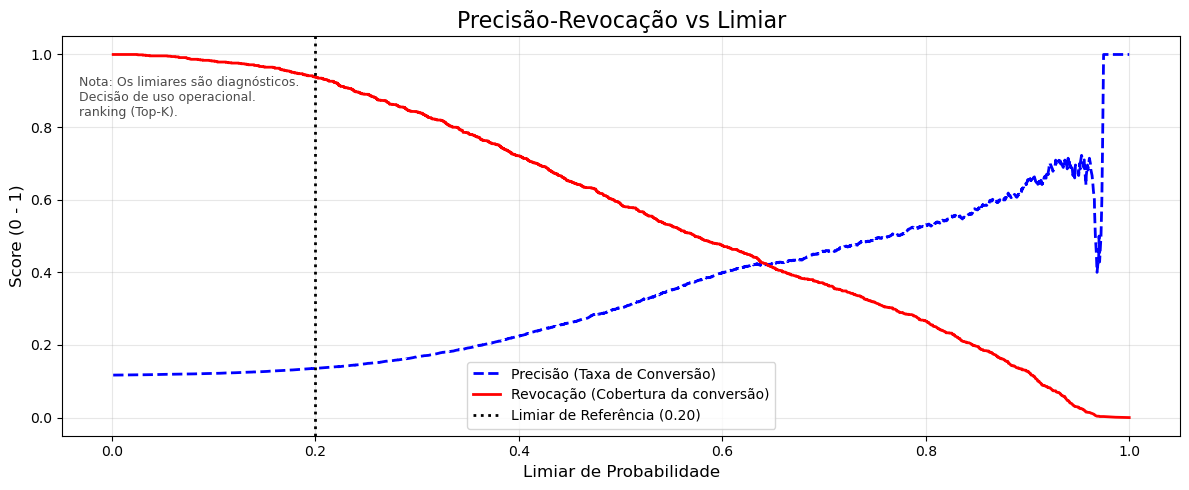

In [56]:
# -----------------------------------------------------------
# 1. Obter probabilidades para a classe positiva (Subscription)
# -----------------------------------------------------------
y_proba = grid_xgb.best_estimator_.predict_proba(X_test)[:, 1]

# -----------------------------------------------------------
# 2. Calcular precision e recall
# -----------------------------------------------------------
precision, recall, thresholds = precision_recall_curve(y_test_num, y_proba)

# thresholds tem tamanho n-1, precision e recall tamanho n
thresholds_plot = np.append(thresholds, 1.0)  # para alinhar os comprimentos (opcional)

plt.figure(figsize=(12, 5))

# Plot Precision e Recall vs Threshold
plt.plot(thresholds_plot, precision, 'b--', label='Precisão (Taxa de Conversão)', linewidth=2)
plt.plot(thresholds_plot, recall, 'r-', label='Revocação (Cobertura da conversão)', linewidth=2)

# -----------------------------------------------------------
# 3. Marcar um threshold de referência para análise de trade-off
# -----------------------------------------------------------
threshold_candidato = 0.2  # exemplo operacional
plt.axvline(threshold_candidato, color='black', linestyle=':', 
            label=f'Limiar de Referência ({threshold_candidato:.2f})', linewidth=2)

# -----------------------------------------------------------
# 4. Ajustes de estética
# -----------------------------------------------------------
plt.title('Precisão-Revocação vs Limiar', fontsize=16)
plt.xlabel('Limiar de Probabilidade', fontsize=12)
plt.ylabel('Score (0 - 1)', fontsize=12)
plt.grid(alpha=0.3)
plt.legend(loc='best')

plt.text(
    0.015, 0.90,
    "Nota: Os limiares são diagnósticos.\nDecisão de uso operacional.\nranking (Top-K).",
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment="top",
    alpha=0.7
)

plt.tight_layout()

# plt.savefig("Curvas Precisão-Recall.svg", format="svg")

plt.show()

* Probabilidades preditas e calibração

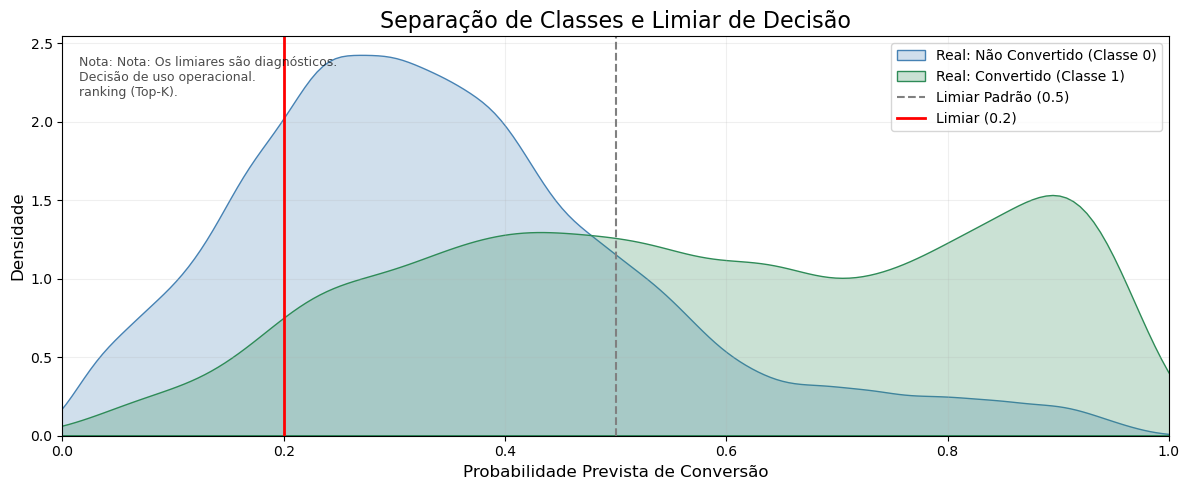

In [58]:
plt.figure(figsize=(12, 5))

# 1. Distribuição para os indivíduos não convertidos (Classe 0)
sns.kdeplot(
    y_proba[y_test_num == 0],
    fill=True,
    color="steelblue",
    label="Real: Não Convertido (Classe 0)",
    bw_adjust=0.7
)

# 2. Distribuição para os indivíduos convertidos (Classe 1)
sns.kdeplot(
    y_proba[y_test_num == 1],
    fill=True,
    color="seagreen",
    label="Real: Convertido (Classe 1)",
    bw_adjust=0.7
)

# 3. Linhas de Threshold para Comparação
plt.axvline(0.5, color="gray", linestyle="--", label="Limiar Padrão (0.5)")
plt.axvline(0.2, color="red", linestyle="-", linewidth=2, label="Limiar (0.2)")

# 4. Formatação Técnica
plt.title("Separação de Classes e Limiar de Decisão", fontsize=16)
plt.xlabel("Probabilidade Prevista de Conversão",fontsize=12)
plt.ylabel("Densidade", fontsize=12)
plt.xlim(0, 1)
plt.legend(loc='best')
plt.grid(alpha=0.2)

plt.text(
    0.015, 0.95,
    "Nota: Nota: Os limiares são diagnósticos.\nDecisão de uso operacional.\nranking (Top-K).",
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment="top",
    alpha=0.7
)

plt.tight_layout()

# plt.savefig("Separação de Classes.svg", format="svg")

plt.show()

* Calibração

Score de Brier (Conversão): 0.1657


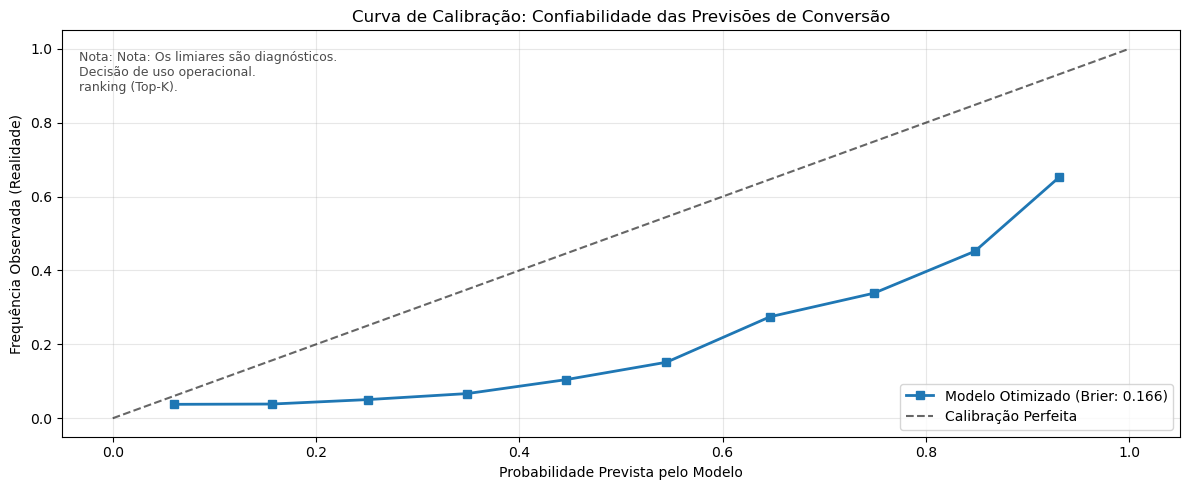

In [59]:
# 1. Calcular a Curva de Calibração
# n_bins=10 divide as probabilidades em fatias de 10%
prob_true, prob_pred = calibration_curve(y_test_num, y_proba, n_bins=10)

# 2. Calcular Brier Score (Quanto menor, melhor a calibração)
brier = brier_score_loss(y_test_num, y_proba)
print(f"Score de Brier (Conversão): {brier:.4f}")

# 3. Plotagem
plt.figure(figsize=(12, 5))
plt.plot(prob_pred, prob_true, marker='s', linewidth=2, label=f'Modelo Otimizado (Brier: {brier:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.6, label='Calibração Perfeita')

plt.xlabel('Probabilidade Prevista pelo Modelo')
plt.ylabel('Frequência Observada (Realidade)')
plt.title('Curva de Calibração: Confiabilidade das Previsões de Conversão')
plt.legend(loc='best')
plt.grid(alpha=0.3)

plt.text(
    0.015, 0.95,
    "Nota: Nota: Os limiares são diagnósticos.\nDecisão de uso operacional.\nranking (Top-K).",
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment="top",
    alpha=0.7
)

plt.tight_layout()

# plt.savefig("Score de Brier.svg", format="svg")


plt.show()

* Curvas ROC-AUC

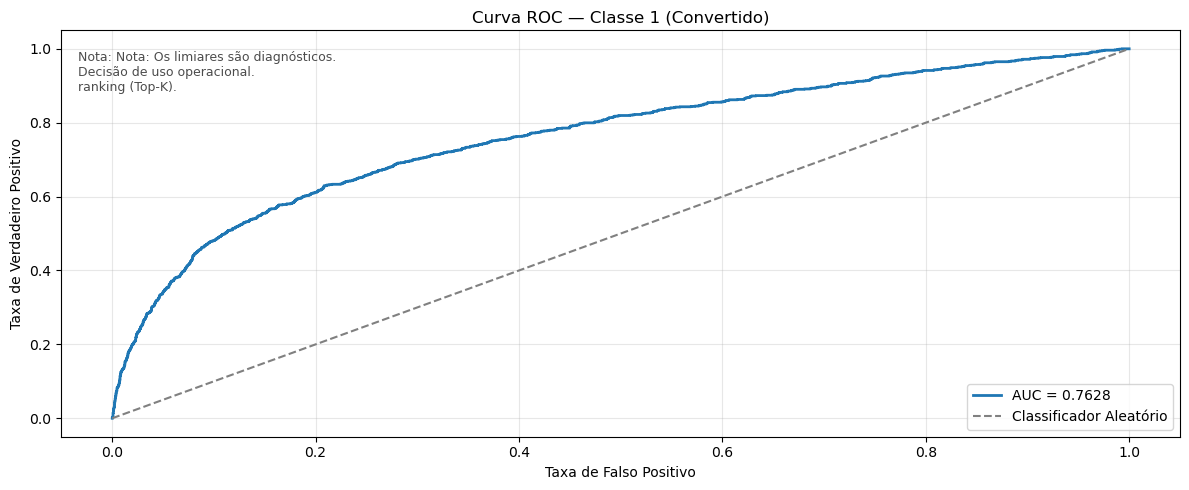

In [62]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# AUC
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(12, 5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Classificador Aleatório")

plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.title("Curva ROC — Classe 1 (Convertido)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.text(
    0.015, 0.95,
    "Nota: Nota: Os limiares são diagnósticos.\nDecisão de uso operacional.\nranking (Top-K).",
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment="top",
    alpha=0.7
)

plt.tight_layout()

# plt.savefig("Curva ROC-AUC.svg", format="svg")

plt.show()

* Matriz de confusão

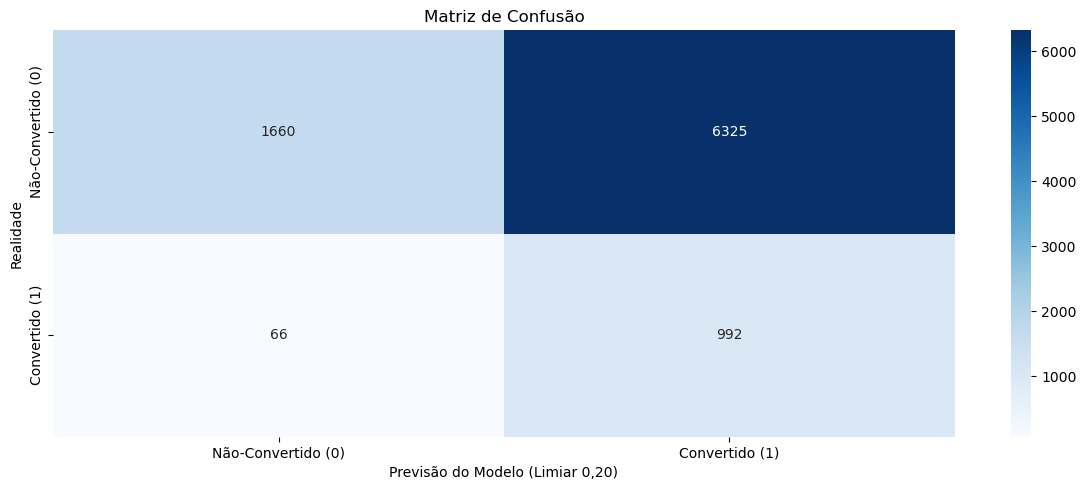

Sensibilidade (Conversão): 93.76%
Casos de Conversão Identificados: 992
Casos de Conversão Não Detectados (Falsos Negativos): 66


In [64]:
# 1. Aplicar o Threshold de 0.20 (definido nas análises anteriores)
# Isso transforma probabilidades em classes (0 ou 1)
y_pred_clinico = (y_proba >= 0.20).astype(int)

# 2. Gerar a Matriz de Confusão
cm = confusion_matrix(y_test_num, y_pred_clinico)

# 3. Plotagem
plt.figure(figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=['Não-Convertido (0)', 'Convertido (1)'], 
            yticklabels=['Não-Convertido (0)', 'Convertido (1)'])

plt.xlabel("Previsão do Modelo (Limiar 0,20)")
plt.ylabel("Realidade")
plt.title("Matriz de Confusão")
plt.tight_layout()

# plt.savefig("Matriz de Confusão.svg", format="svg")


plt.show()

# 4. Extração de Métricas de Negócio
tn, fp, fn, tp = cm.ravel()
recall = tp / (tp + fn)
print(f"Sensibilidade (Conversão): {recall:.2%}")
print(f"Casos de Conversão Identificados: {tp}")
print(f"Casos de Conversão Não Detectados (Falsos Negativos): {fn}")

* Eficiência de triagem

,decile,population_%,cumulative_gain_%,cumulative_lift,precision_at_k
0,1,10.008,37.996,3.797,0.444
1,2,20.004,55.860,2.792,0.327
2,3,30.001,65.974,2.199,0.257
3,4,39.998,73.724,1.843,0.216
4,5,50.006,79.773,1.595,0.187
5,6,60.002,84.310,1.405,0.164
6,7,69.999,89.036,1.272,0.149
7,8,79.996,93.478,1.169,0.137
8,9,89.992,96.881,1.077,0.126
9,10,100.000,100.000,1.000,0.117


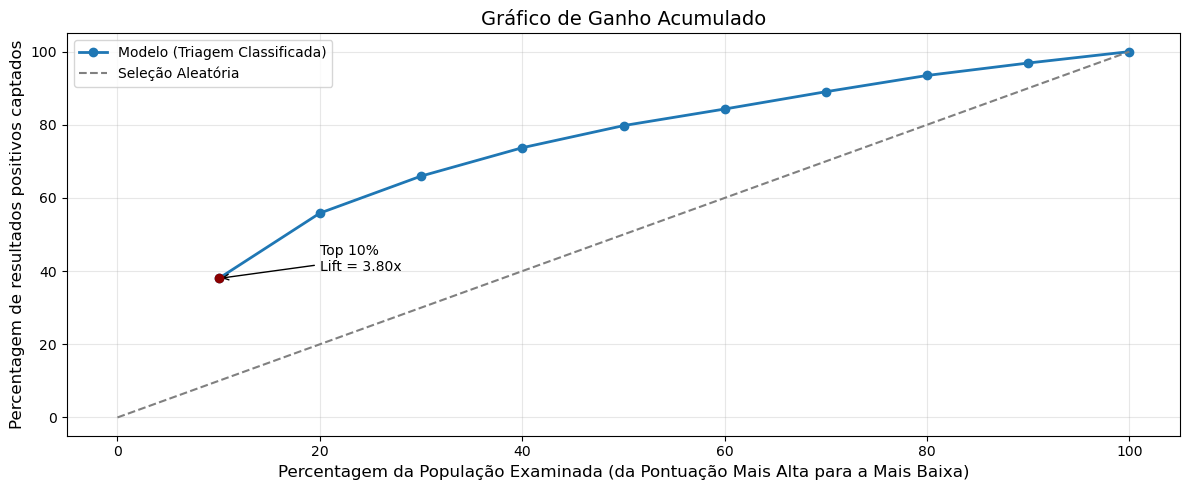

In [67]:
df_triage = pd.DataFrame({
    "y_true": y_test_num.reset_index(drop=True),
    "y_proba": y_proba
})

# Ordenar do maior risco / propensão para o menor
df_triage = df_triage.sort_values(
    "y_proba", ascending=False
).reset_index(drop=True)

# Criar decis baseados no RANKING (não no valor da probabilidade)
df_triage["decile"] = pd.qcut(
    np.arange(len(df_triage)),
    q=10,
    labels=np.arange(1, 11)
)

total_positives = df_triage["y_true"].sum()
base_rate = total_positives / len(df_triage)

gains_table = (
    df_triage
    .groupby("decile", observed=True)
    .agg(
        population=("y_true", "count"),
        positives=("y_true", "sum")
    )
    .reset_index()
)

# Cálculos acumulados
gains_table["cum_population"] = gains_table["population"].cumsum()
gains_table["cum_positives"] = gains_table["positives"].cumsum()

gains_table["population_%"] = gains_table["cum_population"] / len(df_triage) * 100
gains_table["cumulative_gain_%"] = gains_table["cum_positives"] / total_positives * 100

# Lift acumulado (métrica estratégica)
gains_table["cumulative_lift"] = (
    gains_table["cumulative_gain_%"] / gains_table["population_%"]
)

# Precision acumulada (opcional, mas muito útil)
gains_table["precision_at_k"] = (
    gains_table["cum_positives"] / gains_table["cum_population"]
)

display(
    gains_table[
        [
            "decile",
            "population_%",
            "cumulative_gain_%",
            "cumulative_lift",
            "precision_at_k"
        ]
    ].round(3)
)

plt.figure(figsize=(12, 5))

plt.plot(
    gains_table["population_%"],
    gains_table["cumulative_gain_%"],
    marker="o",
    linewidth=2,
    label="Modelo (Triagem Classificada)"
)

# Linha aleatória (baseline)
plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    color="gray",
    label="Seleção Aleatória"
)

plt.title("Gráfico de Ganho Acumulado", fontsize=14)
plt.xlabel("Percentagem da População Examinada (da Pontuação Mais Alta para a Mais Baixa)", fontsize=12)
plt.ylabel("Percentagem de resultados positivos captados", fontsize=12)

# Destaque operacional (Top 10%)
top10 = gains_table.iloc[0]

plt.scatter(
    top10["population_%"],
    top10["cumulative_gain_%"],
    color="darkred",
    zorder=5
)

plt.annotate(
    f"Top 10%\nLift = {top10['cumulative_lift']:.2f}x",
    xy=(top10["population_%"], top10["cumulative_gain_%"]),
    xytext=(20, 40),
    arrowprops=dict(arrowstyle="->")
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# plt.savefig("Lift.svg", format="svg")

plt.show()

* Shap summary

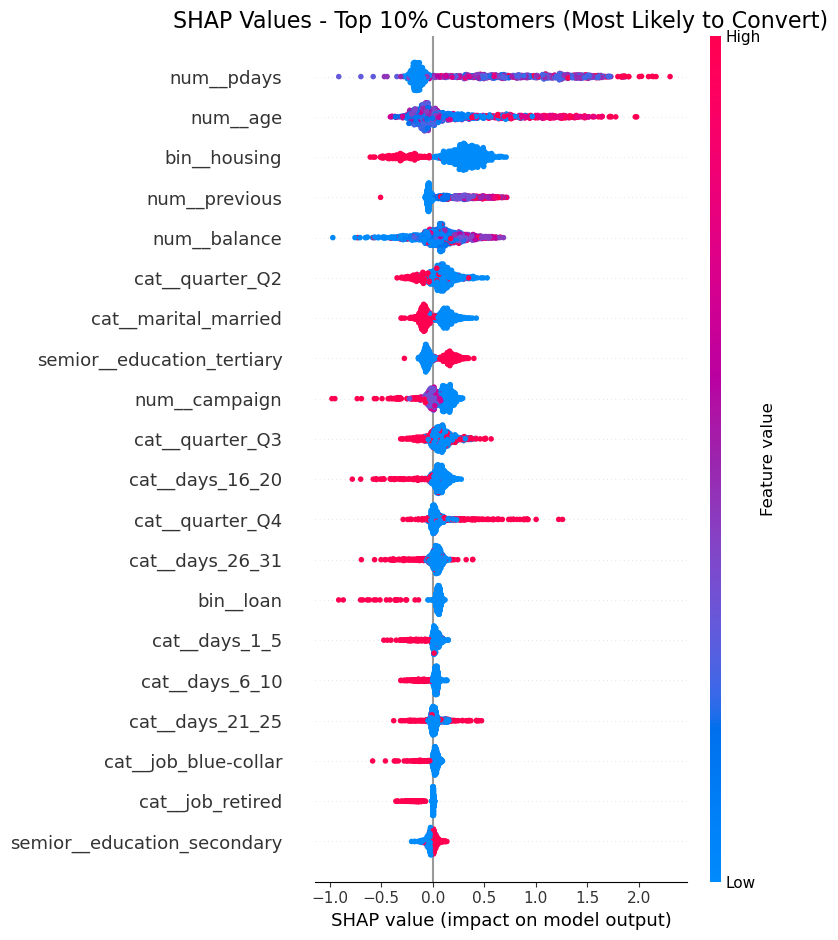

In [68]:
# Recuperar componentes do pipeline (ajuste o nome do seu pipeline se necessário)
best_pipeline = grid_xgb.best_estimator_
classifier_model = best_pipeline.named_steps['model']
preprocessor_step = best_pipeline.named_steps['preprocess']

# 1. Criar o df_test_transformed (Obrigatório para o SHAP e para a filtragem)
X_test_transformed = preprocessor_step.transform(X_test)
feature_names = preprocessor_step.get_feature_names_out()
df_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names)

# 2. Inicializar o Explainer e calcular SHAP
explainer = shap.TreeExplainer(classifier_model)
# O parâmetro check_additivity=False é útil se houver pequenas discrepâncias de float
shap_values = explainer.shap_values(df_test_transformed, check_additivity=False)

# 3. Tratamento para garantir a classe positiva (1) se for uma lista
if isinstance(shap_values, list):
    shap_values_target_full = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_target_full = shap_values[:, :, 1]
else:
    shap_values_target_full = shap_values

# 4. Identificar o Top 10%
y_probs = best_pipeline.predict_proba(X_test)[:, 1]
threshold_10_percent = np.percentile(y_probs, 90)
top_10_indices = np.where(y_probs >= threshold_10_percent)[0]

# 5. Filtrar dados e valores SHAP usando os índices
df_test_top_10 = df_test_transformed.iloc[top_10_indices]
shap_values_top_10 = shap_values_target_full[top_10_indices]

# 6. Plotagem final
plt.figure(figsize=(12, 10))
plt.title(f"SHAP Values - Top 10% Customers (Most Likely to Convert)", fontsize=16)
shap.summary_plot(
    shap_values_top_10, 
    df_test_top_10, 
    show=False
)
plt.tight_layout()
plt.show()

* Shap dependence plot

SHAP Calculated for 9043 records...
Sucesso! Analisando 905 clientes com maior score.


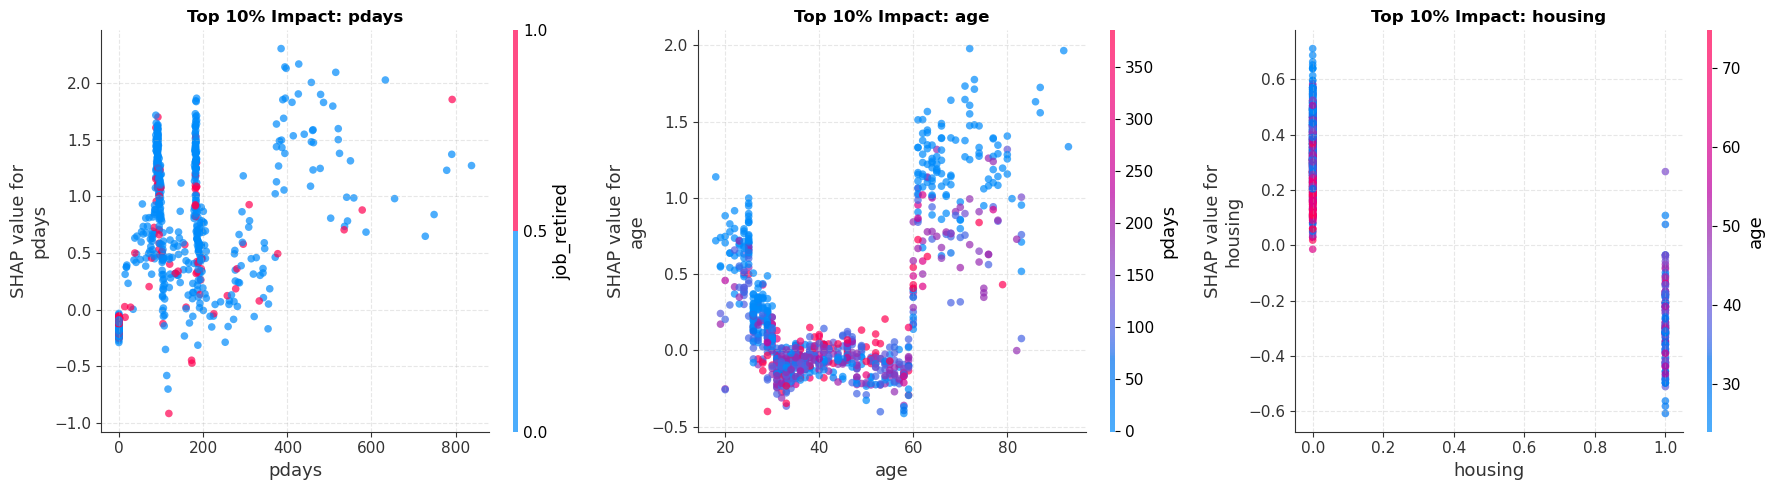

In [69]:
# ==============================================================================
# 1. PREPARAÇÃO DOS DADOS TOTAIS (GARANTINDO ALINHAMENTO)
# ==============================================================================

# Transformar X_test completo e garantir nomes de colunas
X_test_transformed = preprocessor_step.transform(X_test)
feature_names = preprocessor_step.get_feature_names_out()
df_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names)

# Criar base de exibição com nomes limpos e valores reais (para o eixo X do gráfico)
X_display = df_test_transformed.copy()
X_display.columns = [col.split('__')[-1] for col in X_display.columns]

# Restaurar valores originais para colunas numéricas (Age, Duration, etc)
cols_numericas_reais = ['duration', 'age', 'balance', 'campaign', 'pdays']
for col in cols_numericas_reais:
    if col in X_display.columns:
        X_display[col] = X_test[col].values
    else:
        # Busca flexível caso o nome tenha mudado no preprocessor
        cols_match = [c for c in X_display.columns if col in c]
        if cols_match:
            X_display[cols_match[0]] = X_test[col].values

# ==============================================================================
# 2. CÁLCULO DO SHAP PARA A BASE COMPLETA
# ==============================================================================

print(f"SHAP Calculated for {len(df_test_transformed)} records...")
explainer = shap.TreeExplainer(classifier_model)
shap_values_raw = explainer.shap_values(df_test_transformed, check_additivity=False)

# Tratamento para garantir a classe positiva (1)
if isinstance(shap_values_raw, list):
    shap_values_target = shap_values_raw[1]
elif len(shap_values_raw.shape) == 3:
    shap_values_target = shap_values_raw[:, :, 1]
else:
    shap_values_target = shap_values_raw

# ==============================================================================
# 3. FILTRAGEM DO TOP K@10% (OS MELHORES CLIENTES)
# ==============================================================================

# Obter probabilidades de conversão
y_probs = best_pipeline.predict_proba(X_test)[:, 1]

# Definir threshold do Top 10% (Percentil 90)
threshold_10_percent = np.percentile(y_probs, 90)
top_10_indices = np.where(y_probs >= threshold_10_percent)[0]

# Aplicar o filtro (Corrigido para top_10)
X_display_top10 = X_display.iloc[top_10_indices]
shap_values_top10 = shap_values_target[top_10_indices]

print(f"Sucesso! Analisando {len(top_10_indices)} clientes com maior score.")

# ==============================================================================
# 4. IDENTIFICAÇÃO E PLOTAGEM DAS TOP FEATURES NO TOP 10%
# ==============================================================================

# Calcular importância local (Média absoluta dos valores SHAP apenas no Top 10%)
local_importance = np.abs(shap_values_top10).mean(0)
feature_imp_df = pd.DataFrame({
    'feature': X_display_top10.columns,
    'importance': local_importance
}).sort_values(by='importance', ascending=False)

# Selecionar as 3 features que mais influenciam o Top 10%
top_3_features = feature_imp_df['feature'].head(3).tolist()

# Plotagem
n_features = len(top_3_features)
fig, axes = plt.subplots(nrows=1, ncols=n_features, figsize=(6*n_features, 5))

# Garantir que axes seja iterável mesmo com 1 feature
if n_features == 1: 
    axes = [axes]

for i, feature_name in enumerate(top_3_features):
    shap.dependence_plot(
        feature_name, 
        shap_values_top10, 
        X_display_top10, 
        interaction_index="auto", 
        ax=axes[i], 
        show=False,
        alpha=0.7, 
        dot_size=30
    )
    axes[i].set_title(f"Top 10% Impact: {feature_name}", fontsize=12, fontweight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

* Shap force plot

In [70]:
# ==============================================================================
# 1. CRIAR O DATAFRAME DE EXIBIÇÃO (X_display) - BASE COMPLETA
# ==============================================================================
# Usamos o DataFrame completo transformado anteriormente
X_display = df_test_transformed.copy()

# A. Limpar os nomes das colunas
X_display.columns = [col.split('__')[-1] for col in X_display.columns]

# B. Injetar os valores REAIS (Alinhado com X_test completo)
cols_reais = ['age', 'job', 'marital', 'education',	
              'default', 'balance', 'housing',
              'loan', 'campaign', 'pdays', 'previous', 'days', 'quarter']

X_raw_full = X_test.copy()

for col in cols_reais:
    if col in X_display.columns:
        X_display[col] = X_raw_full[col].values

# ==============================================================================
# 2. CÁLCULOS DO SHAP E SELEÇÃO DA CLASSE 1 (XGBOOST)
# ==============================================================================

# A. Ajuste do Valor Base (Expected Value)
# Para XGBoost Binário, o expected_value costuma ser um escalar único (em log-odds)
base_value = explainer.expected_value

# Se por algum motivo o explainer retornar uma lista (comum em certas versões/configurações)
if isinstance(base_value, (list, np.ndarray)) and len(base_value) > 1:
    base_value = base_value[1]

print(f"Valor Base do XGBoost (Log-Odds): {base_value:.4f}")

# B. Garantir SHAP Values da Classe 1
# 'shap_values_target' já foi definido no passo anterior como a matriz da Classe 1
shap_vals_target = shap_values_target 

# C. Encontrar índices extremos na BASE COMPLETA
# Calculamos a predição final somando o base_value aos impactos SHAP
total_predictions = shap_vals_target.sum(axis=1) + base_value

idx_high = np.argmax(total_predictions) # Posição do cliente "Mais Provável"
idx_low = np.argmin(total_predictions)  # Posição do cliente "Menos Provável"

print(f"High Probability Client (Posição {idx_high}): Log-odds ≈ {total_predictions[idx_high]:.2f}")
print(f"Low Probability Client (Posição {idx_low}): Log-odds ≈ {total_predictions[idx_low]:.2f}")

# ==============================================================================
# 3. GERAR FORCE PLOTS INTERATIVOS (LOGIT LINK)
# ==============================================================================
def plot_force_xgb(idx_pos, title):
    print(f"\n--- {title} ---")
    
    # Inicializa JS no notebook
    shap.initjs()
    
    # link='logit' converte de log-odds para probabilidade real (0 a 1)
    # Isso é essencial para tornar o gráfico interpretável para humanos
    display(shap.force_plot(
        base_value,
        shap_vals_target[idx_pos],
        X_display.iloc[idx_pos, :],
        link="logit", 
        matplotlib=False 
    ))

# Gerar os Gráficos de "Ato de Fé" (Alta Probabilidade) e "Rejeição" (Baixa Probabilidade)
plot_force_xgb(idx_high, "Profile: Maximum Probability of Conversion")
plot_force_xgb(idx_low, "Profile: Lowest Probability of Conversion")

Valor Base do XGBoost (Log-Odds): 0.0016
High Probability Client (Posição 2604): Log-odds ≈ 4.29
Low Probability Client (Posição 5851): Log-odds ≈ -6.66

--- Profile: Maximum Probability of Conversion ---



--- Profile: Lowest Probability of Conversion ---


# Salvando o Modelo

In [67]:
# 1. Extrair o pipeline vencedor (Pré-processamento + Modelo)
modelo_final = grid_xgb.best_estimator_

# 2. Salvar em um arquivo .pkl
joblib.dump(modelo_final, 'modelo_bank_marketing_xgboost.pkl')

['modelo_bank_marketing_xgboost.pkl']

# Síntese